# Тесты и демонстрация сходимости методов

Отдельный ноутбук для тестов и визуализаций, вынесенных из `zadachi_metody_minimuma.ipynb`.
Определения методов продублированы сюда, чтобы ноутбук был самодостаточным и запускался сверху вниз.

**Порядок прогона:** `Restart Kernel and Run All`.

Проверяется три идеи:
1. метод парабол на наборе граничных случаев;
2. сравнение всех методов (золотое сечение, бисекция по f′, парабола, хорды, Брент) на 13 тестовых функциях;
3. метод Ньютона на наборе граничных случаев + визуализация сходимости.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


## Определения методов (продублированы)


In [2]:
def golden_section(f, a, b, eps=1e-6, max_iter=100):
   
    phi = (1 + 5**0.5) / 2   # 1.618...
    k1 = 1 - 1 / phi          # 0.382
    k2 = 1 / phi              # 0.618

    # Первые две внутренние точки
    x1 = a + k1 * (b - a)
    x2 = a + k2 * (b - a)

    f1 = f(x1)
    f2 = f(x2)
    func_calls = 2  # счётчик вызовов функции

    for iteration in range(max_iter):
        current_len = b - a        

        if current_len < eps:
            break        

        if f1 < f2:
            # Минимум слева → [a, x2]
            b = x2
            x2 = x1  # старая x1 → новая x2
            f2 = f1
            x1 = a + k1 * (b - a) # считаем только одну новую точку
            f1 = f(x1)
            func_calls += 1
        else:
            # Минимум справа → [x1, b]
            a = x1
            x1 = x2                    # старая x2 → новая x1
            f1 = f2
            x2 = a + k2 * (b - a)
            f2 = f(x2)   # считаем только одну новую точку
            func_calls += 1

    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1
    return x_opt, f_opt, iteration + 1, func_calls

def bisection(f, a, b, eps=1e-6, max_iter=1000):

    f_a = f(a)
    f_b = f(b)
    func_calls = 2  # счётчик вызовов функции

    if f_a * f_b > 0:
        raise ValueError(
        f"на концах отрезка функция одного знака: "
        f"f({a}) = {f_a:.4g}, f({b}) = {f_b:.4g}; "
        f"деление пополам требует смены знака на [a; b]"
        )
    
    for iteration in range(max_iter):
        x = (a + b) / 2
        f_x = f(x)
        func_calls += 1

        if f_x == 0:
            return x, f_x, iteration + 1, func_calls
        
        if b - a < eps:
            return x, f_x, iteration + 1, func_calls
        
        if f_a * f_x < 0:
            b = x 
            f_b = f_x 
        else:
            a = x
            f_a = f_x

    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1


# принимает на вход первую производную
def secant_method(f1, a, b, eps=1e-3, max_iter=100):
    x0, x1 = a, b

    f_x0 = f1(x0)
    f_x1 = f1(x1)

    func_calls = 2

    xi, f_xi = x1, f_x1

    for iteration in range(max_iter):

        # Защита от деления на ноль или почти ноль
        if abs(f_x1 - f_x0) < 1e-12:
            ok = abs(f_x1) <= eps and a < x1 < b
            return x1, f_x1, iteration + 1, func_calls, ok

        # Считаем новую точку
        xi = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        f_xi = f1(xi)
        func_calls += 1

        # Критерий останова по шагу. Сошлись только если в найденной
        # точке производная действительно близка к нулю: промежуточные
        # итерации секущей могут выходить за отрезок, это нормально.
        if abs(xi - x1) < eps:
            ok = abs(f_xi) <= eps and a < xi < b
            return xi, f_xi, iteration + 1, func_calls, ok

        # Обновляем точки: забываем самую старую
        x0 = x1
        f_x0 = f_x1

        x1 = xi
        f_x1 = f_xi

    return xi, f_xi, max_iter, func_calls, False

ZERO_EPS = 1e-12
def newton(f1, f2, x0, eps=1e-3, max_iter=100):
    
    func_calls = 0  # счётчик вызовов функции

    for iteration in range(max_iter):

        f1_x0 = f1(x0)
        f2_x0 = f2(x0) 
        func_calls += 2        

        if abs(f2_x0) < ZERO_EPS:                      
            return x0, f1_x0, iteration +1, func_calls, False
        else:   
            #вычисляем новую точку
            x1 = x0 - f1_x0 / f2_x0

        f1_x1 = f1(x1)
        func_calls += 1

        if abs(x1 - x0) < eps:
            return x1, f1_x1, iteration + 1, func_calls, True

        x0 = x1      
    return x0, f1_x0, iteration +1, func_calls, False

def parabolic(f, a, b, eps=1e-6, max_iter=100):
    # находим третью точку
    c = (a + b) / 2  
    f_a, f_b, f_c = f(a), f(b), f(c)
    
    # проверяем, что функция в середине меньше, чем на концах
    if f_c > f_a or f_c > f_b:
        raise ValueError("середина отрезка не является самой низкой точкой")
    
    # x1=a, x2=c, x3=b
    x1, x2, x3 = a, c, b
    f1, f2, f3 = f_a, f_c, f_b
    func_calls = 3  # счётчик вызовов f

    #считаем вершину параболы  
    for iteration in range(max_iter):
      
        D1 = (f2 - f1) / (x2 - x1)
        D2 = (f3 - f2) / (x3 - x2)
        A = (D2 - D1) / (x3 - x1)

        if abs(A) < 1e-12:
            # возвращаем текущую лучшую точку
            return x2, f2, iteration + 1, False, func_calls
        
        # Вершина параболы 
        x_new = (x1 + x2) / 2 - D1 / (2 * A)
        f_new = f(x_new)
        func_calls += 1

        if abs(x_new - x2) < eps:
            return x_new, f_new, iteration + 1, True, func_calls

        points = [(x1, f1), (x2, f2), (x3, f3), (x_new, f_new)]
        points.sort(key=lambda p: p[0]) 

        worst = max(points, key=lambda point: point[1]) 
        points.remove(worst)

        x1, f1 = points[0]
        x2, f2 = points[1]
        x3, f3 = points[2]

    return x2, f2, max_iter, False, func_calls

def brent(f, a, b, eps=1e-3, max_iter=100):
    # a, b	границы текущего отрезка
    # x	лучшая точка (самое низкое f)
    # w	вторая по качеству точка
    # v	третья по качеству точка
    # fx, fw, fv	значения функции в этих точках
    # u	новая точка-кандидат
    # d	шаг, сделанный в прошлый раз
    # e	шаг, сделанный перед d
    # c_gold = (3−√5)/2	константа золотого сечения ≈ 0.382

    c_gold = (3 - math.sqrt(5)) / 2 
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1

    for iteration in range (max_iter):
        if (b - a) < eps:
            break

        u = None

        if e != 0 and v != w and w != x and v != x:
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)

            if abs(A) > 1e-12: 
                apex = (x + w) / 2 - D1 / (2 * A)

                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex

        if u is None: 
            if x < (a + b) / 2: #если в левой половине
                u = x + (b - x) * c_gold
            else:
                u = x - (x - a) * c_gold

        e = d
        d = u - x
        fu = f(u)
        func_calls += 1

        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u >= x:
                b = u
            else:
                a = u

            if fu <= fw or w == x:
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

    return x, fx, func_calls, iteration 
                                                


## 1. Тестирование метода парабол


In [3]:
import numpy as np

def test_parabolic():
    tests = [
        # (имя, функция, [a, b], точный ответ, eps, ожидаемый результат)
        ("1. Парабола",          lambda x: (x - 3)**2,          [0, 6],   3.0,   1e-6, True),
        ("2. Узкая парабола",    lambda x: 10000*(x - 1.5)**2,  [0, 3],   1.5,   1e-6, True),
        ("3. Широкая парабола",  lambda x: 0.0001*(x + 2)**2,   [-5, 5], -2.0,   1e-6, True),
        ("4. Обратная парабола", lambda x: -x**2,               [0, 10],  None,  1e-6, "error"),
        ("5. Минимум не в центре", lambda x: (x - 1)**2,        [0, 10],  None,  1e-6, "error"),
        ("6. Два минимума",      lambda x: x**4 - 2*x**2,       [-2, -0.5], -1.0, 1e-6,  True),
        ("7. Линейная (2x+1)",   lambda x: 2*x + 1,             [0, 10],  None,  1e-6, "error"), 
        ("8. Минимум вне отрезка", lambda x: (x - 3)**2 + 10*x, [0, 4],   None,  1e-6, "error"),
        ("9. Прямая без наклона",    lambda x: 5,              [0, 10],  None,  1e-6, False),  # константа: A=0, метод возвращает success=False, а не падает
        ("10. Неск. мин/макс",         lambda x: np.sin(x),    [2, 6],   3*np.pi/2, 1e-6, True),
        ("11. sin (минимум внутри)",   lambda x: np.sin(x),    [2, 6],   3*np.pi/2, 1e-6, True),
        ("12. tg (монотонна)",         lambda x: np.tan(x),    [0, 1],   None,  1e-6, "error"),
        ("13. exp (монотонна)",        lambda x: np.exp(x),    [0, 2],   None,  1e-6, "error"),
    ]

    for name, f, bounds, true_x, eps, expected in tests:

        if expected == "error":
            try:
                parabolic(f, bounds[0], bounds[1], eps=eps)
                print(f"❌ {name}: ожидалась ошибка, но метод не упал")
            except (ValueError, ZeroDivisionError):
                print(f"✅ {name}: ошибка поймана (как и ожидалось)")

        else:
            try:                                                    
                x, _, _, success, calls = parabolic(f, bounds[0], bounds[1], eps=eps)
            except Exception as e:
                print(f"❌ {name}: неожиданная ошибка — {e}")
                continue

            ok = success == expected
            if true_x is not None:
                ok = ok and abs(x - true_x) < eps * 10
            print(f"{'✅' if ok else '❌'} {name}: x={x:.6f}, success={success}, вызовов={calls}")

if __name__ == "__main__":
    test_parabolic()


✅ 1. Парабола: x=3.000000, success=True, вызовов=4
✅ 2. Узкая парабола: x=1.500000, success=True, вызовов=4
✅ 3. Широкая парабола: x=-2.000000, success=True, вызовов=5
✅ 4. Обратная парабола: ошибка поймана (как и ожидалось)
✅ 5. Минимум не в центре: ошибка поймана (как и ожидалось)
✅ 6. Два минимума: x=-1.000000, success=True, вызовов=11
✅ 7. Линейная (2x+1): ошибка поймана (как и ожидалось)
✅ 8. Минимум вне отрезка: ошибка поймана (как и ожидалось)
✅ 9. Прямая без наклона: x=5.000000, success=False, вызовов=3
✅ 10. Неск. мин/макс: x=4.712389, success=True, вызовов=9
✅ 11. sin (минимум внутри): x=4.712389, success=True, вызовов=9
✅ 12. tg (монотонна): ошибка поймана (как и ожидалось)
✅ 13. exp (монотонна): ошибка поймана (как и ожидалось)


### 1.1. Наглядная работа и ограничения


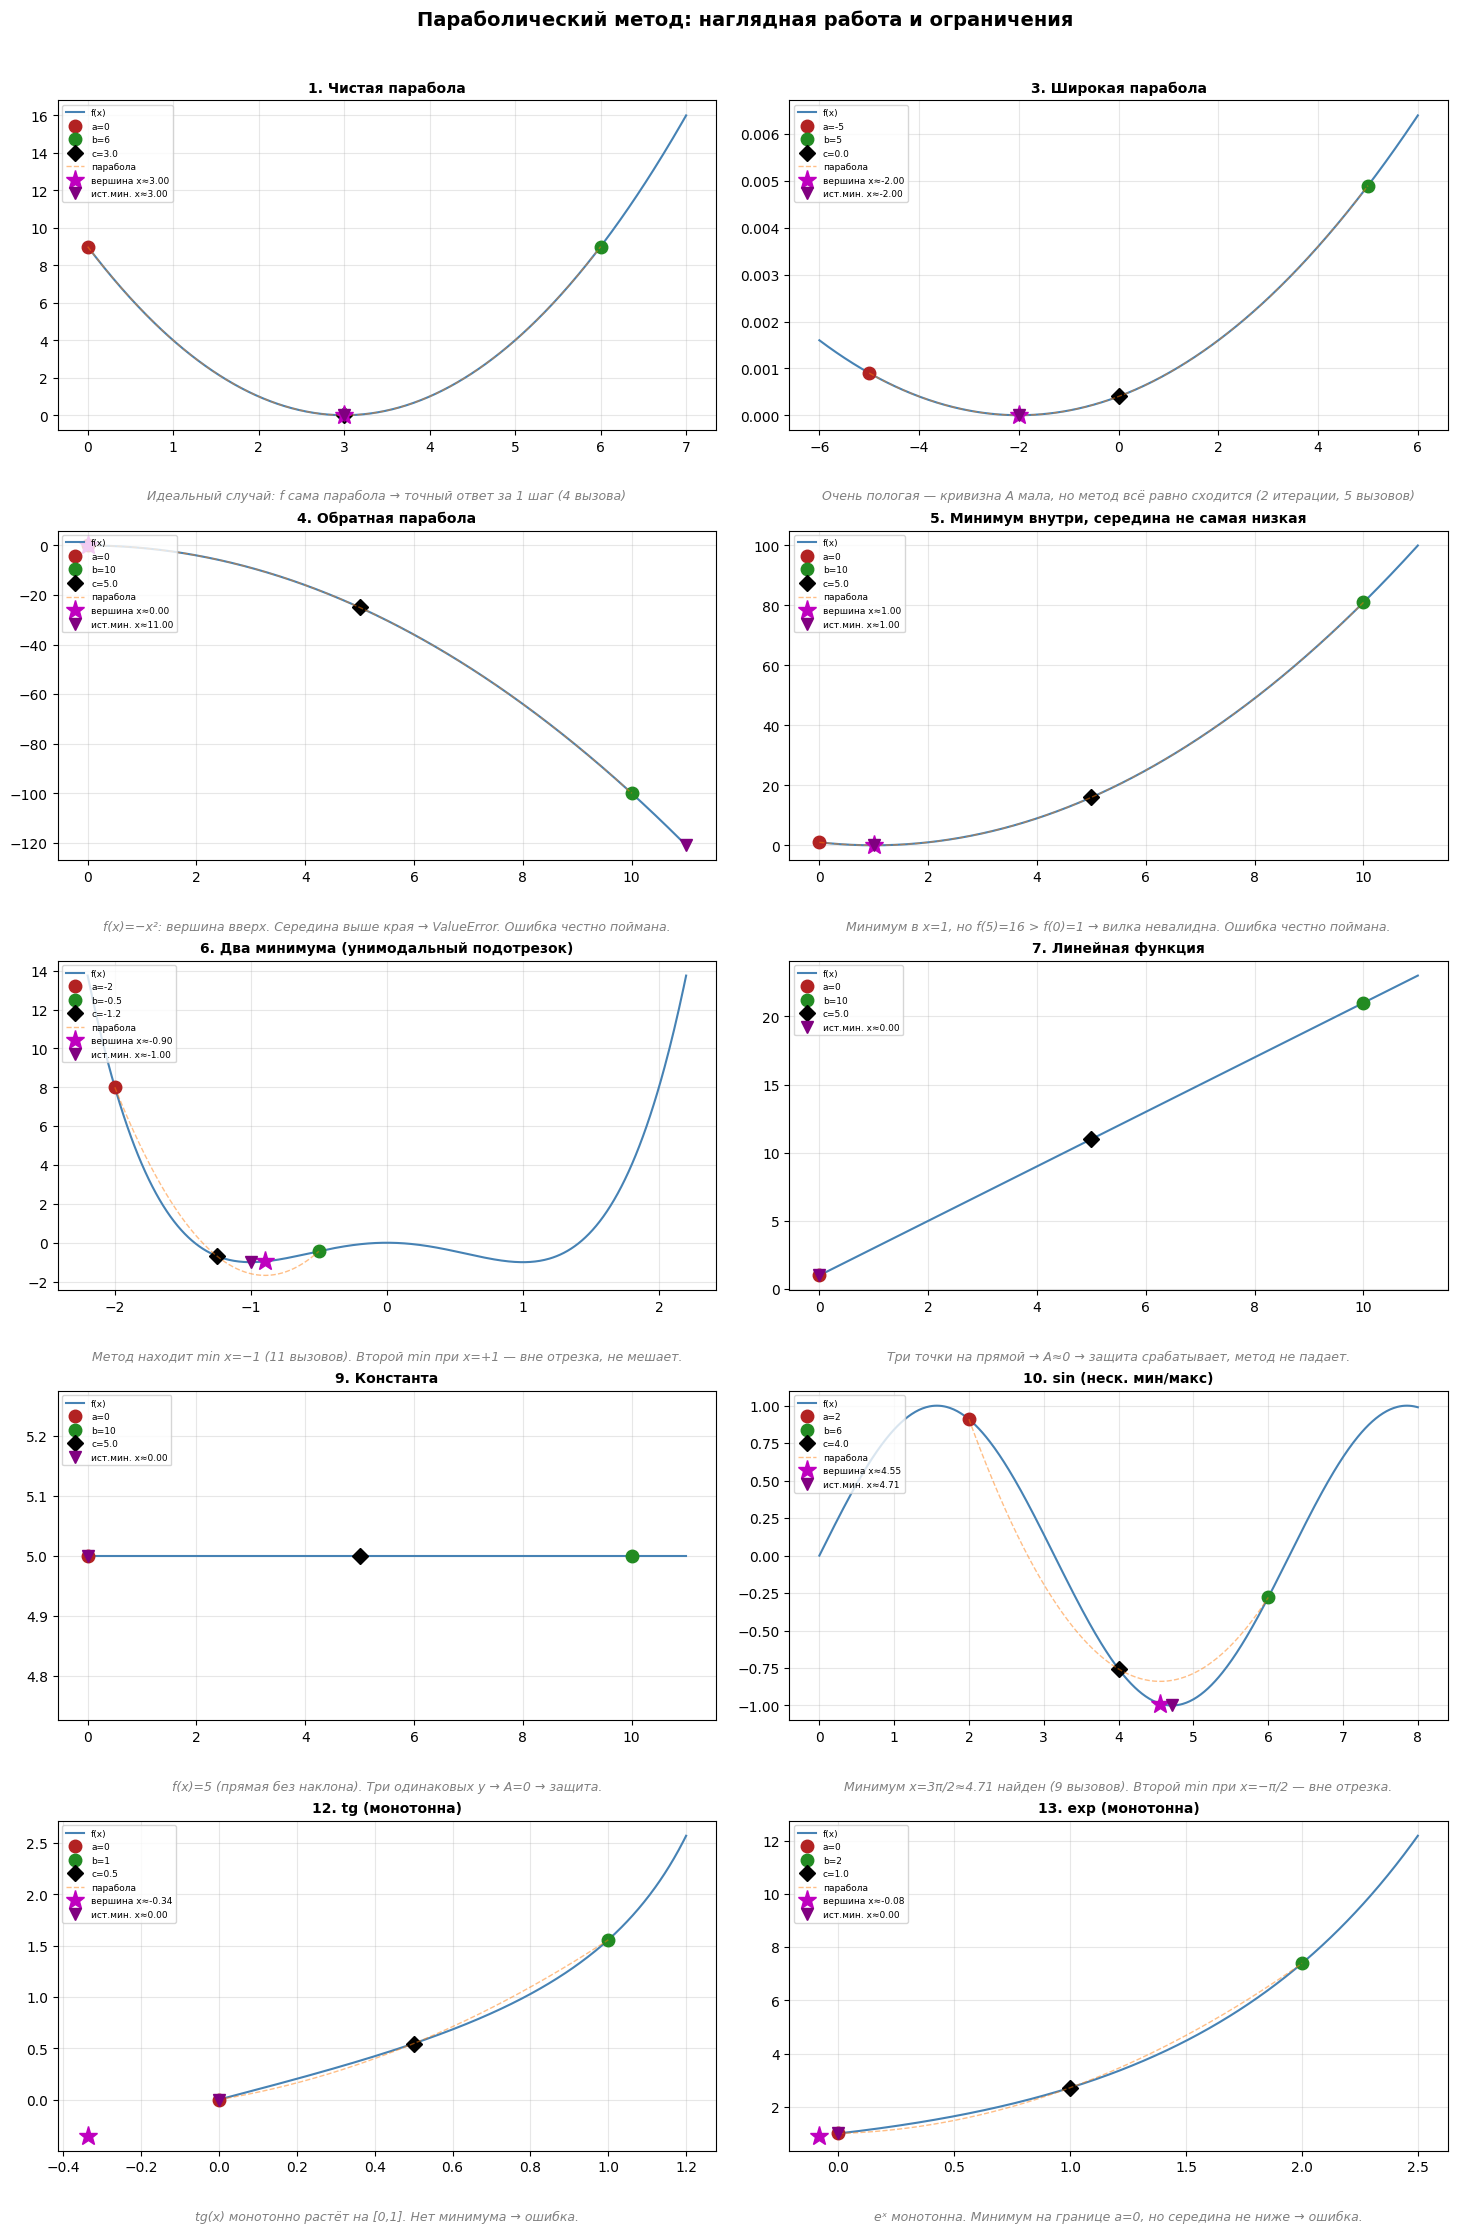

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_one_case(ax, title, f, a, b, x_range, note):
    """Рисует график функции f на [x_range], стартовую тройку (a, c, b),
    проходящую через них параболу и её вершину (если возможно)."""
    c = (a + b) / 2
    fa, fb, fc = f(a), f(b), f(c)

    # Функция
    xs = np.linspace(x_range[0], x_range[1], 500)
    ax.plot(xs, [f(x) for x in xs], 'steelblue', linewidth=1.5, label='f(x)')

    # Стартовая тройка
    ax.plot(a, fa, 'o', color='firebrick', markersize=9, label=f'a={a}')
    ax.plot(b, fb, 'o', color='forestgreen', markersize=9, label=f'b={b}')
    ax.plot(c, fc, 'D', color='black', markersize=8, label=f'c={c:.1f}')

    # Парабола через три точки (если A ≠ 0 и нет ошибки)
    try:
        x1, x2, x3 = a, c, b
        f1, f2, f3 = fa, fc, fb
        D1 = (f2 - f1) / (x2 - x1)
        D2 = (f3 - f2) / (x3 - x2)
        A  = (D2 - D1) / (x3 - x1)
        if abs(A) > 1e-12:
            x_vertex = (x1 + x2) / 2 - D1 / (2 * A)
            # парабола в форме Ньютона
            px = np.linspace(a, b, 200)
            py = f1 + D1 * (px - x1) + A * (px - x1) * (px - x2)
            ax.plot(px, py, 'C1', linestyle='--', alpha=0.5, linewidth=1, label='парабола')
            ax.plot(x_vertex, f(x_vertex), 'm*', markersize=14,
                    label=f'вершина x≈{x_vertex:.2f}')
    except Exception:
        pass

    # Минимум функции на диапазоне x_range (если есть)
    xs_dense = np.linspace(x_range[0], x_range[1], 2000)
    ys_dense = np.array([f(x) for x in xs_dense])
    i_min = np.argmin(ys_dense)
    ax.plot(xs_dense[i_min], ys_dense[i_min], 'v', color='purple',
            markersize=8, label=f'ист.мин. x≈{xs_dense[i_min]:.2f}')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.text(0.5, -0.18, note, transform=ax.transAxes, fontsize=9,
            color='gray', ha='center', va='top', style='italic')
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.3)


def draw_all_parabolic_tests():
    cases = [
        ("1. Чистая парабола",
         lambda x: (x - 3)**2, 0, 6, [0, 7],
         "Идеальный случай: f сама парабола → точный ответ за 1 шаг (4 вызова)"),

        ("3. Широкая парабола",
         lambda x: 0.0001*(x + 2)**2, -5, 5, [-6, 6],
         "Очень пологая — кривизна A мала, но метод всё равно сходится (2 итерации, 5 вызовов)"),

        ("4. Обратная парабола",
         lambda x: -x**2, 0, 10, [0, 11],
         "f(x)=−x²: вершина вверх. Середина выше края → ValueError. Ошибка честно поймана."),

        ("5. Минимум внутри, середина не самая низкая",
         lambda x: (x - 1)**2, 0, 10, [0, 11],
         "Минимум в x=1, но f(5)=16 > f(0)=1 → вилка невалидна. Ошибка честно поймана."),

        ("6. Два минимума (унимодальный подотрезок)",
         lambda x: x**4 - 2*x**2, -2, -0.5, [-2.2, 2.2],
         "Метод находит min x=−1 (11 вызовов). Второй min при x=+1 — вне отрезка, не мешает."),

        ("7. Линейная функция",
         lambda x: 2*x + 1, 0, 10, [0, 11],
         "Три точки на прямой → A≈0 → защита срабатывает, метод не падает."),

        ("9. Константа",
         lambda x: 5, 0, 10, [0, 11],
         "f(x)=5 (прямая без наклона). Три одинаковых y → A=0 → защита."),

        ("10. sin (неск. мин/макс)",
         lambda x: np.sin(x), 2, 6, [0, 8],
         "Минимум x=3π/2≈4.71 найден (9 вызовов). Второй min при x=−π/2 — вне отрезка."),

        ("12. tg (монотонна)",
         lambda x: np.tan(x), 0, 1, [0, 1.2],
         "tg(x) монотонно растёт на [0,1]. Нет минимума → ошибка."),

        ("13. exp (монотонна)",
         lambda x: np.exp(x), 0, 2, [0, 2.5],
         "eˣ монотонна. Минимум на границе a=0, но середина не ниже → ошибка."),
    ]

    fig, axes = plt.subplots(5, 2, figsize=(15, 22))
    axes = axes.flatten()

    for ax, (title, f, a, b, xr, note) in zip(axes, cases):
        plot_one_case(ax, title, f, a, b, xr, note)

    fig.suptitle("Параболический метод: наглядная работа и ограничения",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

draw_all_parabolic_tests()

## 2. Сравнение всех методов на 13 тестовых функциях


In [5]:
import numpy as np
from IPython.display import Markdown, display

# ======== Тестовые случаи (из test_parabolic) ========
tests = [
    ("1. Парабола",          lambda x: (x-3)**2,          lambda x: 2*(x-3),        [0, 6],     3.0),
    ("2. Узкая парабола",    lambda x: 10000*(x-1.5)**2,  lambda x: 20000*(x-1.5),  [0, 3],     1.5),
    ("3. Широкая парабола",  lambda x: 0.0001*(x+2)**2,   lambda x: 0.0002*(x+2),   [-5, 5],    -2.0),
    ("4. Обратная парабола", lambda x: -x**2,             lambda x: -2*x,           [0, 10],    None),
    ("5. Мин. не в центре",  lambda x: (x-1)**2,          lambda x: 2*(x-1),        [0, 10],    1.0),
    ("6. Два минимума",      lambda x: x**4-2*x**2,       lambda x: 4*x**3-4*x,     [-2, -0.5], -1.0),
    ("7. Линейная",          lambda x: 2*x+1,             lambda x: 2,              [0, 10],    None),
    ("8. Мин. вне отр.",     lambda x: (x-3)**2+10*x,     lambda x: 2*(x-3)+10,     [0, 4],     None),
    ("9. Константа",         lambda x: 5,                 lambda x: 0,              [0, 10],    None),
    ("10. sin (мин/макс)",   lambda x: np.sin(x),         lambda x: np.cos(x),      [2, 6],     3*np.pi/2),
    ("11. sin (внутри)",     lambda x: np.sin(x),         lambda x: np.cos(x),      [2, 6],     3*np.pi/2),
    ("12. tg (монотонна)",   lambda x: np.tan(x),         lambda x: 1/np.cos(x)**2, [0, 1],     None),
    ("13. exp (монотонна)",  lambda x: np.exp(x),         lambda x: np.exp(x),      [0, 2],     None),
]

def is_minimum(f, x, a, b, delta=1e-3):
    """Проверяет, что в точке x действительно минимум f на [a,b].

    Берём две соседние точки: слева и справа от x. Если в обеих функция
    больше, чем в x — это минимум. Если меньше — максимум.
    Если x у границы — слегка сдвигаем границу наружу и смотрим поведение."""
    fx = f(x)
    # точка слева от x (у левой границы — расширяем отрезок)
    left = f(x - delta) if x - delta >= a else f(a - delta)
    # точка справа от x (у правой границы — расширяем отрезок)
    right = f(x + delta) if x + delta <= b else f(b + delta)
    return left > fx and right > fx   # с обеих сторон функция выше → минимум

def golden_runner(f, d, a, b):
    try:
        return f"{golden_section(f, a, b, eps=1e-6)[0]:.4f}"
    except Exception:
        return "-"

def bisection_runner(f, d, a, b):
    try:
        x = bisection(d, a, b, eps=1e-6)[0]
    except Exception:
        return "-"
    return f"{x:.4f}" if is_minimum(f, x, a, b) else "-"

def parabolic_runner(f, d, a, b):
    try:
        return f"{parabolic(f, a, b, eps=1e-6)[0]:.4f}"
    except Exception:
        return "-"

def secant_runner(f, d, a, b):
    try:
        x, _, _, _, ok = secant_method(d, a, b, eps=1e-6)
    except Exception:
        return "-"
    if not ok:
        return "-"
    return f"{x:.4f}" if is_minimum(f, x, a, b) else "-"

def brent_runner(f, d, a, b):
    try:
        return f"{brent(f, a, b, eps=1e-6)[0]:.4f}"
    except Exception:
        return "-"

# ======== Таблица ========

METHODS = [
    ("Зол. сечение",  golden_runner),
    ("Бисекция (f')", bisection_runner),
    ("Метод парабол", parabolic_runner),
    ("Метод хорд",    secant_runner),
    ("Метод Брента",  brent_runner),
]

lines = []
lines.append("### Сравнение всех методов на 13 тестовых функциях")
lines.append("")
lines.append("| Тест | Истина | Зол. сечение | Бисекция (f') | Метод парабол | Метод хорд | Метод Брента |")
lines.append("|:---|:---:|:---:|:---:|:---:|:---:|:---:|")

for name, f, d, bounds, true_x in tests:
    a, b = bounds
    true_str = f"{true_x:.4f}" if true_x is not None else "—"
    row = f"| {name} | {true_str} |"
    for mname, runner in METHODS:
        row += f" {runner(f, d, a, b)} |"
    lines.append(row)

lines.append("")
lines.append("*«—» — метод не сработал (ошибка) или нашёл не минимум: корень f' оказался максимумом/перегибом.*")
display(Markdown("\n".join(lines)))


### Сравнение всех методов на 13 тестовых функциях

| Тест | Истина | Зол. сечение | Бисекция (f') | Метод парабол | Метод хорд | Метод Брента |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| 1. Парабола | 3.0000 | 3.0000 | 3.0000 | 3.0000 | 3.0000 | 3.0000 |
| 2. Узкая парабола | 1.5000 | 1.5000 | 1.5000 | 1.5000 | 1.5000 | 1.5000 |
| 3. Широкая парабола | -2.0000 | -2.0000 | -2.0000 | -2.0000 | -2.0000 | -2.0000 |
| 4. Обратная парабола | — | 10.0000 | - | - | - | 10.0000 |
| 5. Мин. не в центре | 1.0000 | 1.0000 | 1.0000 | - | 1.0000 | 1.0000 |
| 6. Два минимума | -1.0000 | -1.0000 | -1.0000 | -1.0000 | -1.0000 | -1.0000 |
| 7. Линейная | — | 0.0000 | - | - | - | 0.0000 |
| 8. Мин. вне отр. | — | 0.0000 | - | - | - | 0.0000 |
| 9. Константа | — | 10.0000 | - | 5.0000 | - | 10.0000 |
| 10. sin (мин/макс) | 4.7124 | 4.7124 | 4.7124 | 4.7124 | 4.7124 | 4.7124 |
| 11. sin (внутри) | 4.7124 | 4.7124 | 4.7124 | 4.7124 | 4.7124 | 4.7124 |
| 12. tg (монотонна) | — | 0.0000 | - | - | - | 0.0000 |
| 13. exp (монотонна) | — | 0.0000 | - | - | - | 0.0000 |

*«—» — метод не сработал (ошибка) или нашёл не минимум: корень f' оказался максимумом/перегибом.*

## 3. Тесты метода Ньютона


In [6]:
import math

def test_newton():
    # (имя, f, f', f'', x0, сходится ли (True/False), примечание)
    tests = [
        # --- Сходится (True) ---
        ("1. Парабола (x−3)²", lambda x: (x - 3)**2,
         lambda x: 2*(x - 3), lambda x: 2.0, 0.0, True, None),
        ("2. Узкая 10000(x−1.5)²", lambda x: 10000*(x - 1.5)**2,
         lambda x: 20000*(x - 1.5), lambda x: 20000.0, 0.0, True, None),
        ("3. Пологая 0.0001(x+2)²", lambda x: 0.0001*(x + 2)**2,
         lambda x: 0.0002*(x + 2), lambda x: 0.0002, 0.0, True, None),
        ("4. Задача 0 (дорога/лес)", lambda x: x/4 + math.sqrt((8 - x)**2 + 9)/3,
         lambda x: 1/4 - (8 - x)/(3*math.sqrt((8 - x)**2 + 9)),
         lambda x: 3/((8 - x)**2 + 9)**1.5, 4.0, True, None),
        ("5. Обратная парабола −x²", lambda x: -x**2,
         lambda x: -2*x, lambda x: -2.0, 2.5, True, "сходится, но это максимум"),
        ("6. x⁴ (плоское дно)", lambda x: x**4,
         lambda x: 4*x**3, lambda x: 12*x**2, 2.0, True, "f″(0)=0, сходимость линейная"),
        ("7. Пологая 10⁻¹⁰·x²", lambda x: 1e-10 * x**2,
         lambda x: 2e-10 * x, lambda x: 2e-10, 1.0, True, "f″=2·10⁻¹⁰, шаг корректен"),

        # --- Не сходится (False) ---
        ("8. x³−3x из 0 (перегиб)", lambda x: x**3 - 3*x,
         lambda x: 3*x**2 - 3, lambda x: 6*x, 0.0, False, "f″=0, f′=−3"),
        ("9. eˣ (нет минимума)", lambda x: math.exp(x),
         lambda x: math.exp(x), lambda x: math.exp(x), 2.0, False, "f′ никогда не 0"),
        ("10. tg (нет корня)", lambda x: math.tan(x),
         lambda x: 1/math.cos(x)**2, lambda x: 2*math.sin(x)/math.cos(x)**3,
         0.5, False, "блуждает"),
        ("11. Линейная 2x+1", lambda x: 2*x + 1,
         lambda x: 2.0, lambda x: 0.0, 2.5, False, "f″=0"),
        ("12. Константа 5", lambda x: 5.0,
         lambda x: 0.0, lambda x: 0.0, 2.5, False, "f′=0 и f″=0"),
        ("13. Цикл 0↔1", lambda x: x**4/4 - x**2 + 2*x,
         lambda x: x**3 - 2*x + 2, lambda x: 3*x**2 - 2, 0.0, False,
         "минимум есть, но метод зацикливается"),
    ]

    passed = 0
    total = len(tests)
    for name, f, f1, f2, x0, expected, note in tests:
        x, f1_val, iters, calls, ok = newton(f1, f2, x0, eps=1e-3, max_iter=100)
        good = (ok == expected)
        if good:
            passed += 1
        suffix = f"  — {note}" if note else ""
        print(f"{'✅' if good else '❌'} {name}: ok={ok}, ожидалось {expected}{suffix}")

    print(f"\nИтог: {passed}/{total} прошло")


test_newton()


✅ 1. Парабола (x−3)²: ok=True, ожидалось True
✅ 2. Узкая 10000(x−1.5)²: ok=True, ожидалось True
✅ 3. Пологая 0.0001(x+2)²: ok=True, ожидалось True
✅ 4. Задача 0 (дорога/лес): ok=True, ожидалось True
✅ 5. Обратная парабола −x²: ok=True, ожидалось True  — сходится, но это максимум
✅ 6. x⁴ (плоское дно): ok=True, ожидалось True  — f″(0)=0, сходимость линейная
✅ 7. Пологая 10⁻¹⁰·x²: ok=True, ожидалось True  — f″=2·10⁻¹⁰, шаг корректен
✅ 8. x³−3x из 0 (перегиб): ok=False, ожидалось False  — f″=0, f′=−3
✅ 9. eˣ (нет минимума): ok=False, ожидалось False  — f′ никогда не 0
✅ 10. tg (нет корня): ok=False, ожидалось False  — блуждает
✅ 11. Линейная 2x+1: ok=False, ожидалось False  — f″=0
✅ 12. Константа 5: ok=False, ожидалось False  — f′=0 и f″=0
✅ 13. Цикл 0↔1: ok=False, ожидалось False  — минимум есть, но метод зацикливается

Итог: 13/13 прошло


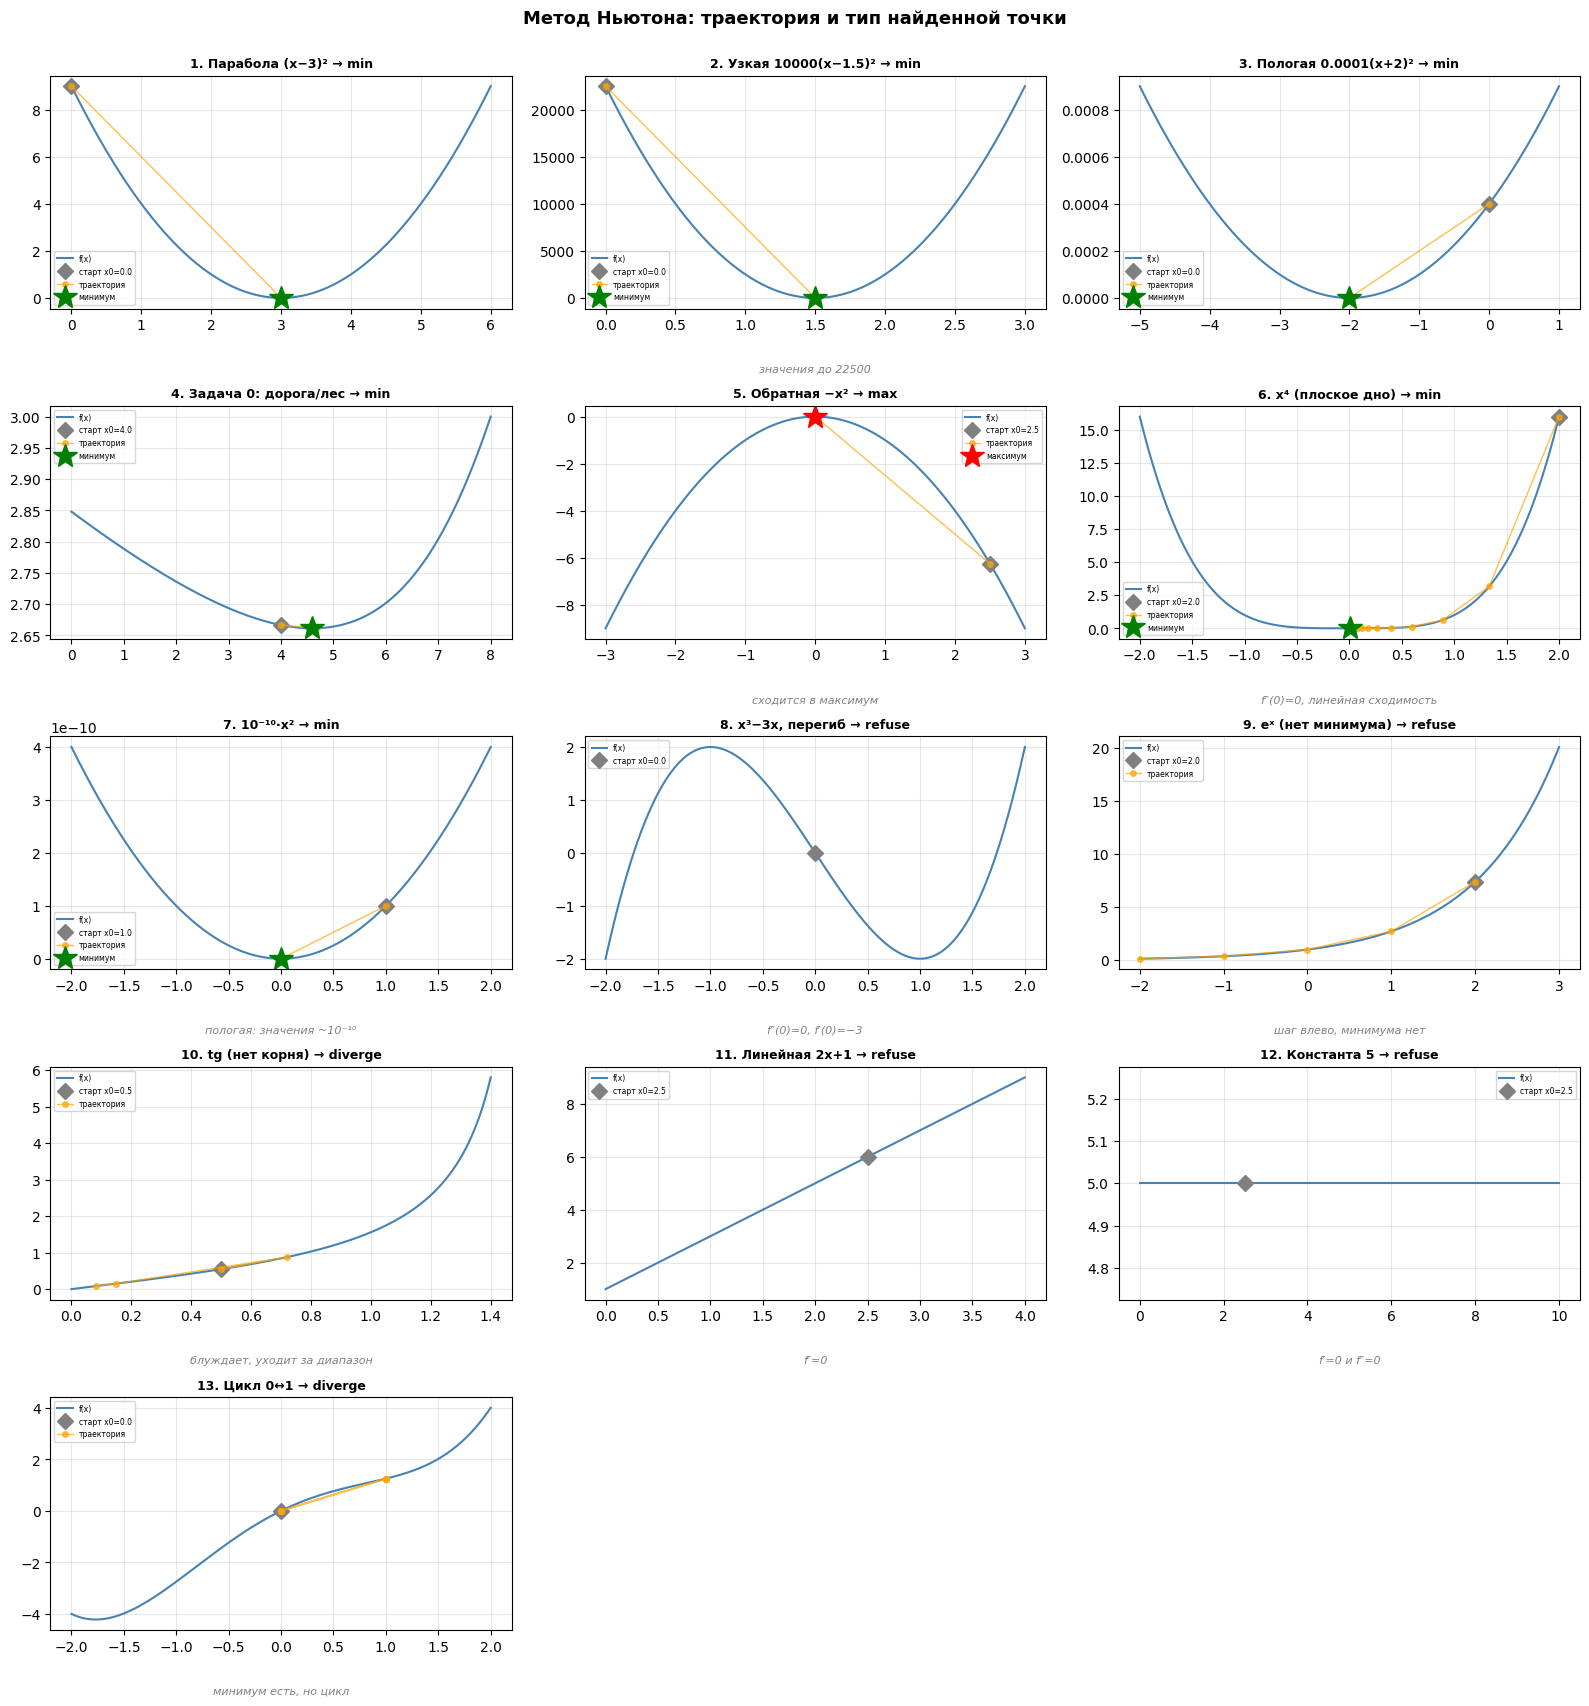

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt


def newton_trace(f1, f2, x0, eps=1e-3, max_iter=100):
    """Возвращает (траектория_x, тип): min / max / refuse / diverge."""
    trace = [x0]
    for it in range(max_iter):
        f1_x0 = f1(x0)
        f2_x0 = f2(x0)
        if abs(f2_x0) < ZERO_EPS:
            return trace, "refuse"
        x1 = x0 - f1_x0 / f2_x0
        trace.append(x1)
        if abs(x1 - x0) < eps:
            return trace, ("min" if f2(x1) > 0 else "max")
        x0 = x1
    return trace, "diverge"


def plot_newton_case(ax, name, f, f1, f2, x0, x_range, note):
    a, b = x_range
    xs = np.linspace(a, b, 600)
    ax.plot(xs, [f(x) for x in xs], 'steelblue', lw=1.5, label='f(x)')

    trace, kind = newton_trace(f1, f2, x0)

    if a <= x0 <= b:
        ax.plot(x0, f(x0), 'D', color='gray', ms=8, label=f'старт x0={x0}')

    inside = [t for t in trace if a <= t <= b][:12]
    if len(inside) > 1:
        ax.plot(inside, [f(t) for t in inside], 'o-', color='orange',
                ms=4, lw=1, alpha=0.7, label='траектория')

    xf = trace[-1]
    if a <= xf <= b:
        if kind == "min":
            ax.plot(xf, f(xf), '*', color='green', ms=18, label='минимум')
        elif kind == "max":
            ax.plot(xf, f(xf), '*', color='red', ms=18, label='максимум')

    ax.set_title(f"{name} → {kind}", fontsize=9, fontweight='bold')
    if note:
        ax.text(0.5, -0.24, note, transform=ax.transAxes, fontsize=8,
                color='gray', ha='center', va='top', style='italic')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=5.5, loc='best')


def draw_all_newton_tests():
    cases = [
        ("1. Парабола (x−3)²", lambda x: (x - 3)**2,
         lambda x: 2*(x - 3), lambda x: 2.0, 0.0, (0, 6), None),
        ("2. Узкая 10000(x−1.5)²", lambda x: 10000*(x - 1.5)**2,
         lambda x: 20000*(x - 1.5), lambda x: 20000.0, 0.0, (0, 3), "значения до 22500"),
        ("3. Пологая 0.0001(x+2)²", lambda x: 0.0001*(x + 2)**2,
         lambda x: 0.0002*(x + 2), lambda x: 0.0002, 0.0, (-5, 1), None),
        ("4. Задача 0: дорога/лес", lambda x: x/4 + math.sqrt((8 - x)**2 + 9)/3,
         lambda x: 1/4 - (8 - x)/(3*math.sqrt((8 - x)**2 + 9)),
         lambda x: 3/((8 - x)**2 + 9)**1.5, 4.0, (0, 8), None),
        ("5. Обратная −x²", lambda x: -x**2,
         lambda x: -2*x, lambda x: -2.0, 2.5, (-3, 3), "сходится в максимум"),
        ("6. x⁴ (плоское дно)", lambda x: x**4,
         lambda x: 4*x**3, lambda x: 12*x**2, 2.0, (-2, 2), "f″(0)=0, линейная сходимость"),
        ("7. 10⁻¹⁰·x²", lambda x: 1e-10 * x**2,
         lambda x: 2e-10 * x, lambda x: 2e-10, 1.0, (-2, 2), "пологая: значения ~10⁻¹⁰"),
        ("8. x³−3x, перегиб", lambda x: x**3 - 3*x,
         lambda x: 3*x**2 - 3, lambda x: 6*x, 0.0, (-2, 2), "f″(0)=0, f′(0)=−3"),
        ("9. eˣ (нет минимума)", lambda x: math.exp(x),
         lambda x: math.exp(x), lambda x: math.exp(x), 2.0, (-2, 3), "шаг влево, минимума нет"),
        ("10. tg (нет корня)", lambda x: math.tan(x),
         lambda x: 1/math.cos(x)**2, lambda x: 2*math.sin(x)/math.cos(x)**3,
         0.5, (0, 1.4), "блуждает, уходит за диапазон"),
        ("11. Линейная 2x+1", lambda x: 2*x + 1,
         lambda x: 2.0, lambda x: 0.0, 2.5, (0, 4), "f″=0"),
        ("12. Константа 5", lambda x: 5.0,
         lambda x: 0.0, lambda x: 0.0, 2.5, (0, 10), "f′=0 и f″=0"),
        ("13. Цикл 0↔1", lambda x: x**4/4 - x**2 + 2*x,
         lambda x: x**3 - 2*x + 2, lambda x: 3*x**2 - 2, 0.0, (-2, 2),
         "минимум есть, но цикл"),
    ]

    cols = 3
    rows = (len(cases) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.4*rows))
    axes = axes.flatten()
    for ax, case in zip(axes, cases):
        plot_newton_case(ax, *case)
    for ax in axes[len(cases):]:
        ax.axis('off')

    fig.suptitle("Метод Ньютона: траектория и тип найденной точки",
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


draw_all_newton_tests()


## 4. Визуализация сходимости Ньютона


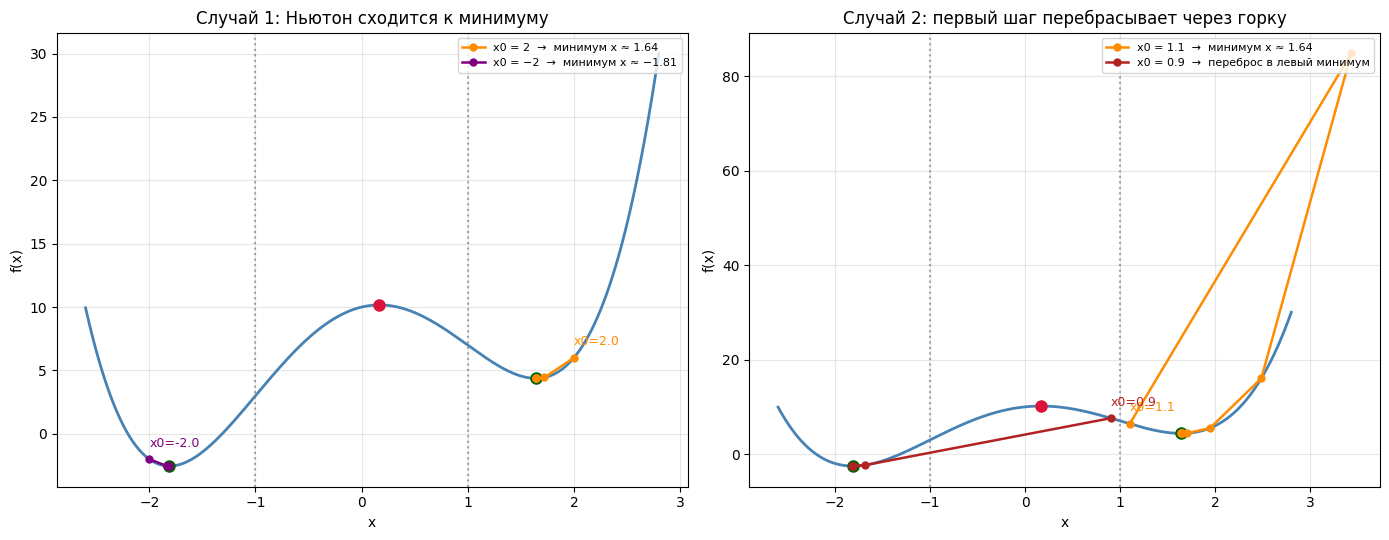

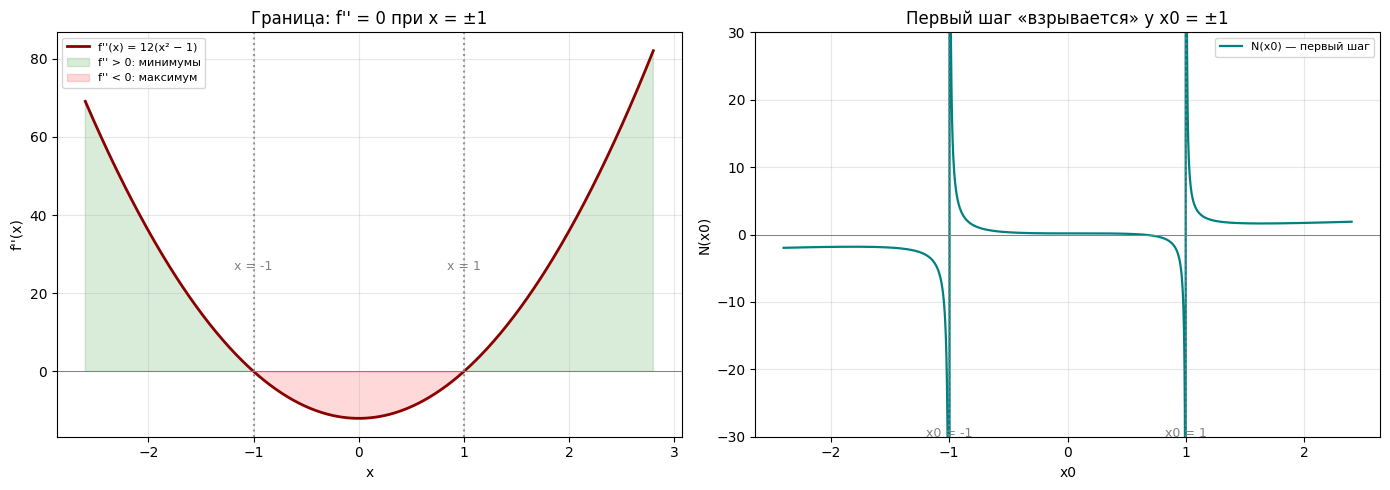

In [8]:
# ============================================================
# Визуализация к заданию 4.3
# f(x) = x^4 - 6x^2 + 2x + 10,  метод Ньютона для f'(x) = 0
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def f(x):   return x**4 - 6*x**2 + 2*x + 10
def f1(x):  return 4*x**3 - 12*x + 2
def f2(x):  return 12*x**2 - 12

def newton_path(f1, f2, x0, eps=1e-3, max_iter=20):
    """История итераций Ньютона: [x0, x1, x2, ...]."""
    path = [x0]
    x = x0
    for _ in range(max_iter):
        if abs(f2(x)) < 1e-12:
            break
        x = x - f1(x) / f2(x)
        path.append(x)
        if abs(path[-1] - path[-2]) < eps:
            break
    return path

# стационарные точки (корни f'=0) и их тип
stat = [(-1.8100, "мин"), (0.1683, "макс"), (1.6418, "мин")]
xs = np.linspace(-2.6, 2.8, 600)

# ---------- Рисунок 1: два случая ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax in axes:
    ax.plot(xs, f(xs), 'steelblue', linewidth=2)
    for r, k in stat:
        ax.plot(r, f(r), 'o', color='darkgreen' if k == "мин" else 'crimson', markersize=8)
    ax.axvline(-1, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(1, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)

def draw_path(ax, x0, color, label):
    p = newton_path(f1, f2, x0)
    ax.plot(p, [f(t) for t in p], 'o-', color=color, linewidth=1.8, markersize=5, label=label)
    ax.annotate(f'x0={x0}', (p[0], f(p[0])), textcoords='offset points',
                xytext=(0, 9), fontsize=9, color=color)

# слева — сходимость за несколько шагов к своему минимуму
draw_path(axes[0], 2.0, 'darkorange', 'x0 = 2  →  минимум x ≈ 1.64')
draw_path(axes[0], -2.0, 'purple', 'x0 = −2  →  минимум x ≈ −1.81')
axes[0].set_title('Случай 1: Ньютон сходится к минимуму')
axes[0].legend(fontsize=8, loc='upper right')

# справа — первый шаг перебрасывает через горку
draw_path(axes[1], 1.1, 'darkorange', 'x0 = 1.1  →  минимум x ≈ 1.64')
draw_path(axes[1], 0.9, 'firebrick', 'x0 = 0.9  →  переброс в левый минимум')
axes[1].set_title('Случай 2: первый шаг перебрасывает через горку')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# ---------- Рисунок 2: граница в f'' ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# слева — f''(x): граница там, где она обнуляется
ax = axes[0]
ax.plot(xs, f2(xs), 'darkred', linewidth=2, label="f''(x) = 12(x² − 1)")
ax.axhline(0, color='gray', linewidth=0.7)
for b in (-1, 1):
    ax.axvline(b, color='gray', linestyle=':', alpha=0.8)
    ax.text(b, 26, f'x = {b}', ha='center', fontsize=9, color='gray')
ax.fill_between(xs, f2(xs), 0, where=f2(xs) > 0, color='green', alpha=0.15, label="f'' > 0: минимумы")
ax.fill_between(xs, f2(xs), 0, where=f2(xs) < 0, color='red', alpha=0.15, label="f'' < 0: максимум")
ax.set_xlabel('x'); ax.set_ylabel("f''(x)")
ax.set_title("Граница: f'' = 0 при x = ±1")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# справа — первый шаг Ньютона N(x0) = x0 - f'/f''
ax = axes[1]
gx = np.linspace(-2.4, 2.4, 2000)
mask = np.abs(f2(gx)) > 1e-9
ax.plot(gx[mask], (gx - f1(gx) / f2(gx))[mask], 'teal', linewidth=1.6, label='N(x0) — первый шаг')
ax.axhline(0, color='gray', linewidth=0.7)
for b in (-1, 1):
    ax.axvline(b, color='gray', linestyle=':', alpha=0.8)
    ax.text(b, -30, f'x0 = {b}', ha='center', fontsize=9, color='gray')
ax.set_ylim(-30, 30)
ax.set_xlabel('x0'); ax.set_ylabel('N(x0)')
ax.set_title('Первый шаг «взрывается» у x0 = ±1')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


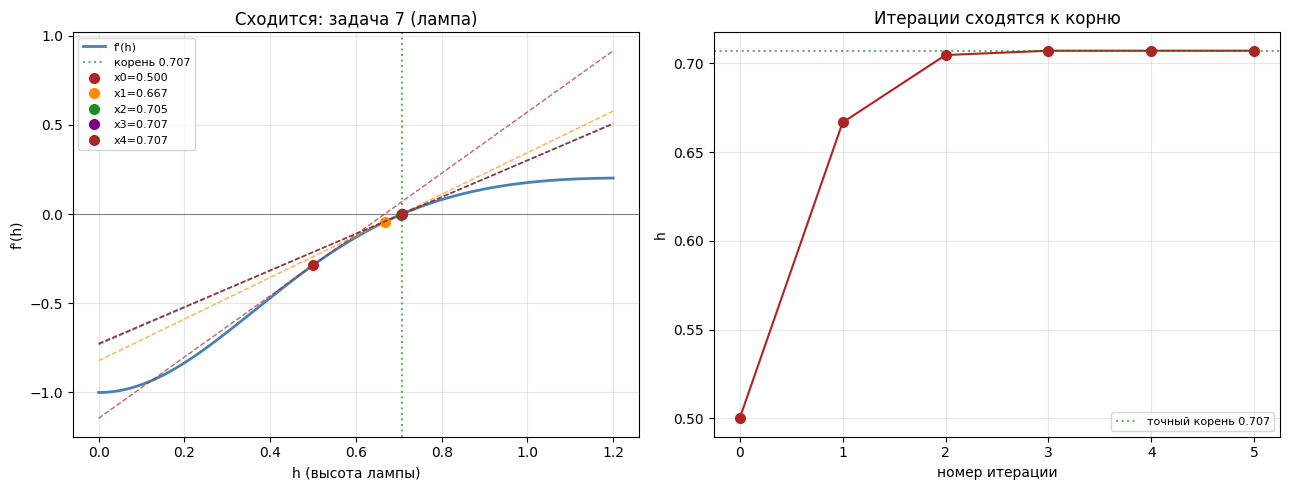

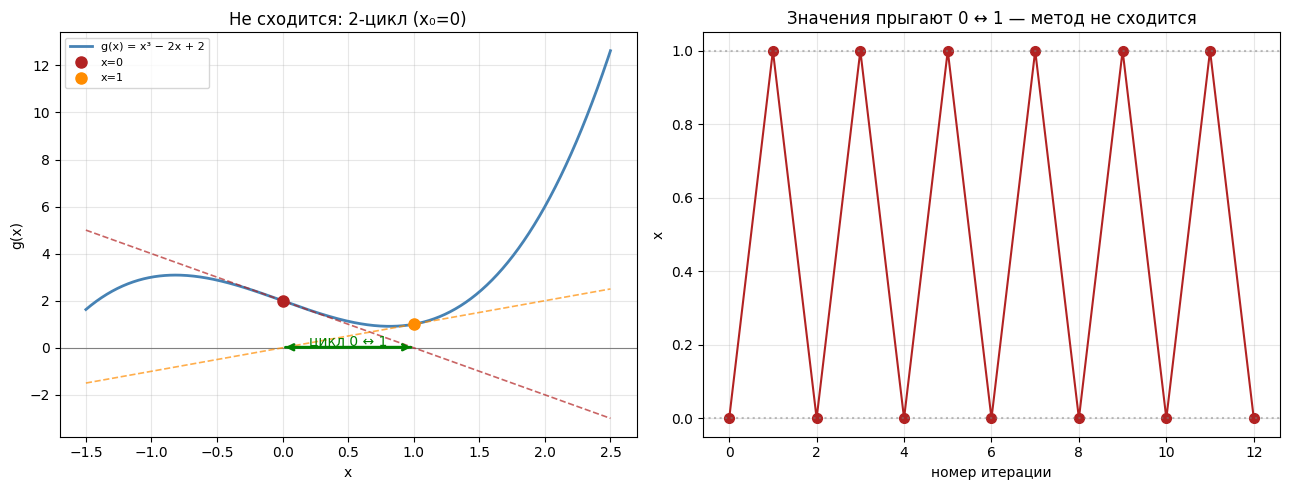

Сходимость (задача 7): ['0.5000', '0.6667', '0.7047', '0.7071', '0.7071', '0.7071']
Не сходится (2-цикл):   ['0.0000', '1.0000', '0.0000', '1.0000', '0.0000', '1.0000', '0.0000', '1.0000', '0.0000', '1.0000', '0.0000', '1.0000', '0.0000']


In [9]:
# ============================================================
# Визуализация метода Ньютона: сходимость и расходимость
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import math


def newton_with_history(f1, f2, x0, eps=1e-6, max_iter=20):
    """Метод Ньютона с сохранением всех итераций [x0, x1, x2, ...]."""
    history = [x0]
    x = x0
    for i in range(max_iter):
        try:
            f1x = f1(x)
            f2x = f2(x)
        except (ValueError, ZeroDivisionError):
            break          # вышли за область определения
        if abs(f2x) < 1e-12:      # защита от деления на ноль
            break
        x_new = x - f1x / f2x     # формула Ньютона
        history.append(x_new)
        if abs(x_new - x) < eps:  # сошлись
            break
        x = x_new
    return history


# ------------------------------------------------------------
# Пример 1: Ньютон СХОДИТСЯ
# Задача 7: лампа над столом
# f'(h) = (2h^2 - 1)/(h^2+1)^2.5,  корень h = 1/sqrt(2) ~ 0.707
# ------------------------------------------------------------
def d1_7(h):
    return (2 * h ** 2 - 1) / (h ** 2 + 1) ** 2.5


def d2_7(h):
    return -3 * h * (2 * h ** 2 - 3) / (h ** 2 + 1) ** 3.5


hist_conv = newton_with_history(d1_7, d2_7, 0.5, max_iter=10)
root_7 = 1 / math.sqrt(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
hs = np.linspace(0, 1.2, 400)
ax.plot(hs, [d1_7(h) for h in hs], 'steelblue', linewidth=2, label="f'(h)")
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(root_7, color='green', linestyle=':', alpha=0.6, label='корень 0.707')

colors = ['firebrick', 'darkorange', 'forestgreen', 'purple', 'brown']
for i, xn in enumerate(hist_conv[:-1]):
    f1xn = d1_7(xn)
    f2xn = d2_7(xn)
    # касательная: y = f'(xn) + f''(xn) * (h - xn)
    ax.plot([0, 1.2], [f1xn + f2xn * (0 - xn), f1xn + f2xn * (1.2 - xn)],
            color=colors[i % len(colors)], linestyle='--', alpha=0.7, linewidth=1)
    ax.plot(xn, f1xn, 'o', color=colors[i % len(colors)], markersize=7,
            label=f'x{i}={xn:.3f}')

ax.set_xlabel('h (высота лампы)')
ax.set_ylabel("f'(h)")
ax.set_title('Сходится: задача 7 (лампа)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(list(range(len(hist_conv))), hist_conv, 'o-', color='firebrick', markersize=7)
ax.axhline(root_7, color='green', linestyle=':', alpha=0.6, label='точный корень 0.707')
ax.set_xlabel('номер итерации')
ax.set_ylabel('h')
ax.set_title('Итерации сходятся к корню')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Пример 2: Ньютон НЕ СХОДИТСЯ (застревает в цикле)
# g(x) = x^3 - 2x + 2, старт x0 = 0
# Касательная в x=0 даёт x=1, в x=1 даёт x=0 -> бесконечный цикл 0 <-> 1
# ------------------------------------------------------------
def g(x):
    return x ** 3 - 2 * x + 2


def gp(x):
    return 3 * x ** 2 - 2


hist_cycle = newton_with_history(g, gp, 0.0, max_iter=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- левый график: касательные, образующие цикл ---
ax = axes[0]
xs = np.linspace(-1.5, 2.5, 400)
ax.plot(xs, [g(x) for x in xs], 'steelblue', linewidth=2, label='g(x) = x³ − 2x + 2')
ax.axhline(0, color='gray', linewidth=0.8)

# касательная в x=0 (даёт следующий x=1) и в x=1 (даёт x=0)
for xn, col in [(0.0, 'firebrick'), (1.0, 'darkorange')]:
    gxn = g(xn)
    gpxn = gp(xn)
    # рисуем касательную по ширине графика
    x_start, x_end = -1.5, 2.5
    ax.plot([x_start, x_end], [gxn + gpxn * (x_start - xn), gxn + gpxn * (x_end - xn)],
            color=col, linestyle='--', alpha=0.7, linewidth=1.2)
    ax.plot(xn, gxn, 'o', color=col, markersize=8, label=f'x={xn:.0f}')

# стрелки цикла 0 -> 1 -> 0
ax.annotate('', xy=(1, 0.02), xytext=(0, 0.02),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('', xy=(0, 0.02), xytext=(1, 0.02),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(0.5, 0.12, 'цикл 0 ↔ 1', color='green', ha='center', fontsize=10)

ax.set_xlabel('x')
ax.set_ylabel('g(x)')
ax.set_title('Не сходится: 2-цикл (x₀=0)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- правый график: итерации прыгают между 0 и 1 ---
ax = axes[1]
ax.plot(list(range(len(hist_cycle))), hist_cycle, 'o-', color='firebrick', markersize=7)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(1, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('номер итерации')
ax.set_ylabel('x')
ax.set_title('Значения прыгают 0 ↔ 1 — метод не сходится')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Сходимость (задача 7):', [f'{x:.4f}' for x in hist_conv])
print('Не сходится (2-цикл):  ', [f'{x:.4f}' for x in hist_cycle])


## 5. Визуализация сходимости метода хорд


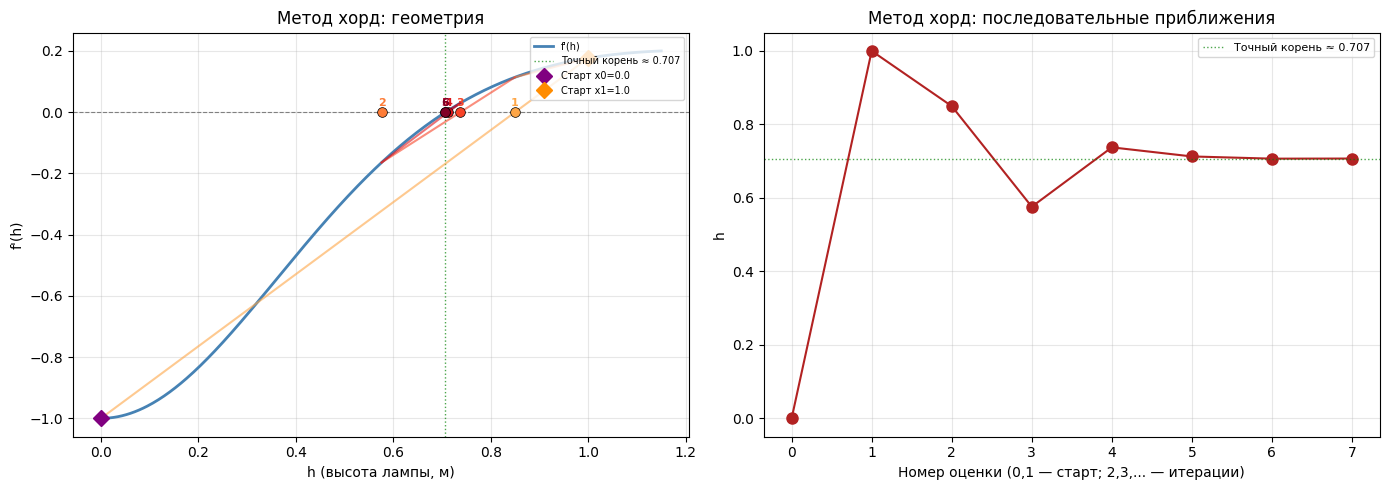

Найденный корень: 0.707110
Точный корень:    0.707107
Потребовалось итераций: 6


In [10]:
# Визуализация сходимости метода хорд
# Задача 7: лампа над круглым столом.
# f'(h) = (2h^2 - 1) / (h^2 + 1)^2.5,  корень h = 1/√2 ≈ 0.707
# Это производная функции f(h) = -h/(h^2+1)^1.5 из таблицы задач
# (освещённость со знаком минус) — знак согласован с генератором таблиц.

import numpy as np
import matplotlib.pyplot as plt

def d1_7(h):
    """Первая производная f(h) = -h/(h^2+1)^1.5 по высоте лампы.
    Корень h = 1/√2 — максимум освещённости."""
    return (2 * h**2 - 1) / (h**2 + 1)**2.5

def secant_with_history(f1, a, b, eps=1e-3, max_iter=100):
    """Метод хорд с сохранением всех шагов для визуализации.
    Возвращает (найденный_корень, история_шагов).
    Каждый шаг: (x0, f0, x1, f1, xi, f_xi, номер_итерации)."""
    x0, x1 = a, b
    f_x0, f_x1 = f1(x0), f1(x1)
    history = []
    
    for iteration in range(max_iter):
        if abs(f_x1 - f_x0) < 1e-12:
            break
        # Формула метода хорд
        xi = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        f_xi = f1(xi)
        
        history.append((x0, f_x0, x1, f_x1, xi, f_xi, iteration))
        
        if abs(xi - x1) < eps:
            break
        # Сдвиг: забываем x0, x1 занимает его место, xi становится новым x1
        x0, f_x0 = x1, f_x1
        x1, f_x1 = xi, f_xi
    
    return xi, history

# Запускаем метод
root, steps = secant_with_history(d1_7, 0.0, 1.0, eps=1e-3)

# Строим график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Левый график: f'(h) и хорды ----
h_vals = np.linspace(0.0, 1.15, 400)
ax1.plot(h_vals, d1_7(h_vals), 'steelblue', linewidth=2, label="f'(h)")
ax1.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax1.axvline(x=1/np.sqrt(2), color='green', linewidth=1, linestyle=':', 
           alpha=0.7, label=f'Точный корень ≈ 0.707')

# Цвета: от оранжевого (первые итерации) до красного (последние)
cmap = plt.cm.YlOrRd
for i, (x0, f0, x1, f1, xi, f_xi, it) in enumerate(steps):
    color = cmap(0.3 + 0.7 * (i + 1) / len(steps))
    # Хорда — прямая через две точки
    ax1.plot([x0, x1], [f0, f1], color=color, linewidth=1.5, alpha=0.6)
    # Точка пересечения хорды с осью X (новое приближение)
    ax1.plot(xi, 0, 'o', color=color, markersize=7, markeredgecolor='black',
            markeredgewidth=0.5)
    # Подписываем номер итерации у точки
    ax1.annotate(f'{it+1}', (xi, 0.02), fontsize=8, color=color,
                ha='center', fontweight='bold')

# Отмечаем x0 (самую первую точку) особым маркером
first_x0 = steps[0][0]
ax1.plot(first_x0, d1_7(first_x0), 'D', color='purple', markersize=8,
        label=f'Старт x0={first_x0}')
first_x1 = steps[0][2]
ax1.plot(first_x1, d1_7(first_x1), 'D', color='darkorange', markersize=8,
        label=f'Старт x1={first_x1}')

ax1.set_xlabel('h (высота лампы, м)')
ax1.set_ylabel("f'(h)")
ax1.set_title('Метод хорд: геометрия')
ax1.legend(fontsize=7, loc='upper right')
ax1.grid(True, alpha=0.3)

# ---- Правый график: приближение к корню от итерации к итерации ----
approx_list = [steps[0][0], steps[0][2]]  # две стартовые точки
for (_, _, _, _, xi, _, _) in steps:
    approx_list.append(xi)

iter_nums = list(range(len(approx_list)))
ax2.plot(iter_nums, approx_list, 'o-', color='firebrick', linewidth=1.5, 
        markersize=8)
ax2.axhline(y=1/np.sqrt(2), color='green', linewidth=1, linestyle=':',
           alpha=0.7, label=f'Точный корень ≈ 0.707')
ax2.set_xlabel('Номер оценки (0,1 — старт; 2,3,... — итерации)')
ax2.set_ylabel('h')
ax2.set_title('Метод хорд: последовательные приближения')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Найденный корень: {root:.6f}')
print(f'Точный корень:    {1/np.sqrt(2):.6f}')
print(f'Потребовалось итераций: {len(steps)}')


## 6. Визуализация сходимости метода Брента

Метод Брента — гибрид: на каждом шаге он сначала пробует прыжок по параболе через три лучшие точки, а если прыжок ненадёжен (вышел за отрезок или больше половины прошлого шага) — откатывается на золотое сечение.

Слева на графике — функция и **все точки, которые метод вычислил по шагам** (старт и u₁, u₂, …), соединённые в порядке итераций. Справа — как ошибка |xₙ − x\*| падает от итерации к итерации.

Номера у точек — номер итерации. Зелёная точка x\* — аналитический ответ задачи.


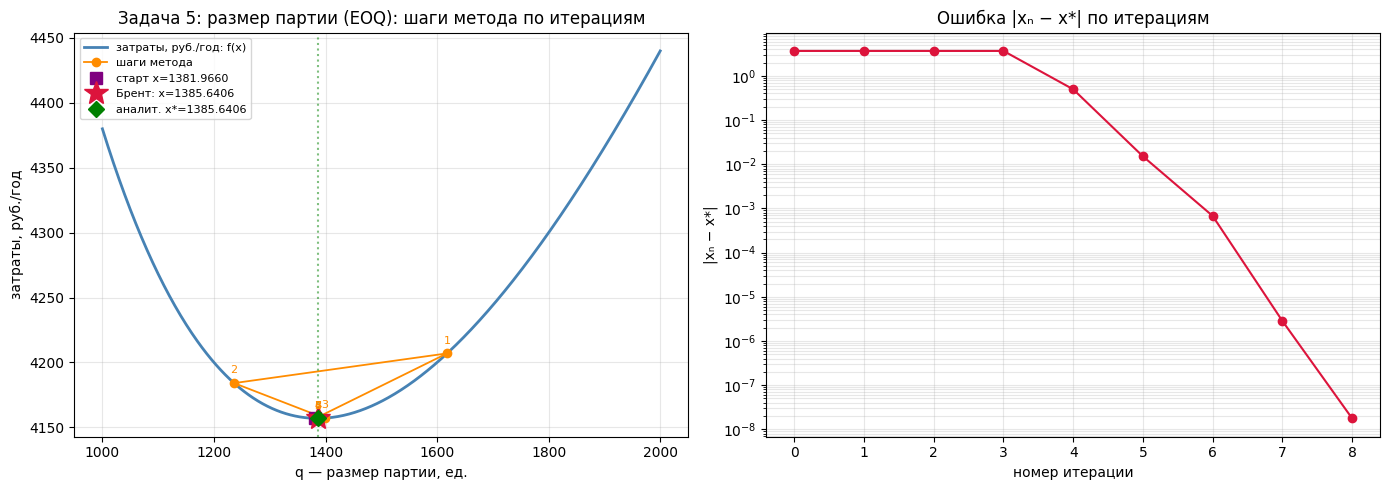

Задача 5: размер партии (EOQ): x = 1385.640646 | вызовов f = 9 | итераций = 8
Шаги (старт + u₁..uₙ): ['1381.9660', '1618.0340', '1236.0680', '1398.2600', '1386.1383', '1385.6558', '1385.6413', '1385.6406', '1385.6406']


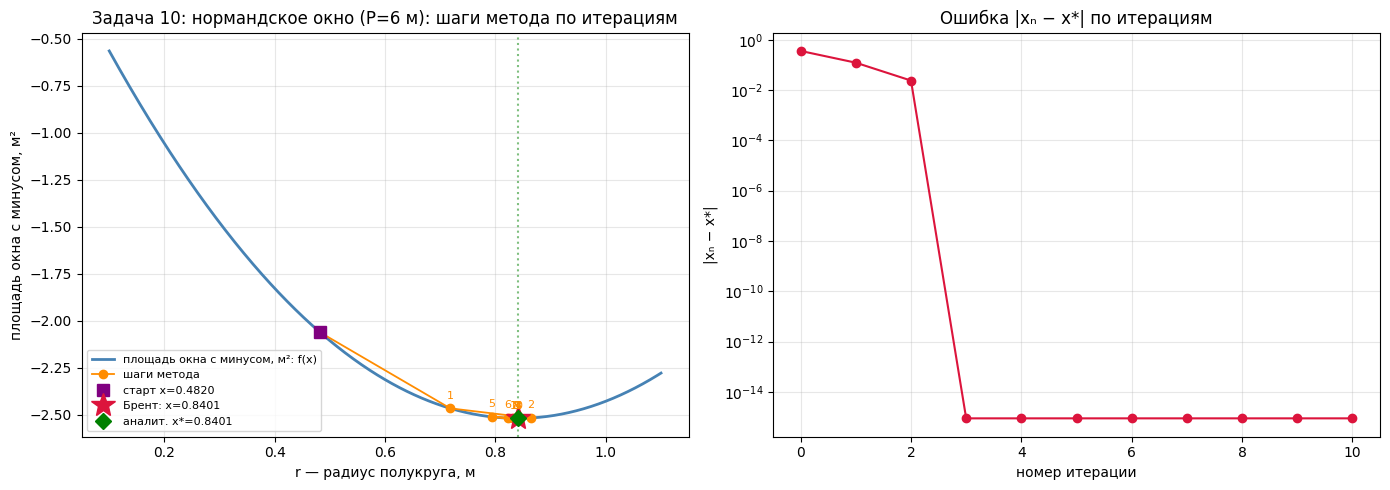

Задача 10: нормандское окно (P=6 м): x = 0.840149 | вызовов f = 11 | итераций = 10
Шаги (старт + u₁..uₙ): ['0.4820', '0.7180', '0.8639', '0.8401', '0.8401', '0.7935', '0.8223', '0.8326', '0.8366', '0.8384', '0.8393']


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math


def brent_with_history(f, a, b, eps=1e-3, max_iter=100):
    """Брент с записью истории: все пробные точки u и лучшая точка x после каждого шага."""
    c_gold = (3 - math.sqrt(5)) / 2
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1
    probes = []     # пробные точки u (что метод «спросил» на шаге)
    bests = [x]     # лучшая точка после каждого шага (старт включён)

    for iteration in range(max_iter):
        if (b - a) < eps:
            break

        u = None
        if e != 0 and v != w and w != x and v != x:
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)
            if abs(A) > 1e-12:
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex

        if u is None:
            if x < (a + b) / 2:
                u = x + (b - x) * c_gold
            else:
                u = x - (x - a) * c_gold

        e = d
        d = u - x
        fu = f(u)
        func_calls += 1
        probes.append(u)

        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u >= x:
                b = u
            else:
                a = u
            if fu <= fw or w == x:
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

        bests.append(x)

    return x, fx, func_calls, iteration, probes, bests


def draw_brent(task_name, f, a, b, analytic, xlabel, fs_label):
    x, fx, fc, iters, probes, bests = brent_with_history(f, a, b, eps=1e-3)

    xs = np.linspace(a, b, 600)
    ys = np.array([f(v) for v in xs])

    # точки, вычисленные методом, в порядке шагов: старт → u₁ → u₂ → …
    all_pts = [bests[0]] + probes
    all_fs = [f(v) for v in all_pts]

    fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(14, 5))

    # --- левый график: функция + шаги метода ---
    ax.plot(xs, ys, 'steelblue', lw=2, label=f'{fs_label}: f(x)')
    ax.plot(all_pts, all_fs, 'o-', color='darkorange', lw=1.3, ms=6,
            label='шаги метода')
    ax.plot(bests[0], f(bests[0]), 's', color='purple', ms=9,
            label=f'старт x={bests[0]:.4f}')
    ax.plot(x, f(x), '*', color='crimson', ms=18, label=f'Брент: x={x:.4f}')
    ax.plot(analytic, f(analytic), 'D', color='green', ms=8,
            label=f'аналит. x*={analytic:.4f}')
    ax.axvline(analytic, color='green', ls=':', alpha=0.5)
    for i, p in enumerate(probes):
        ax.annotate(str(i + 1), (p, f(p)), textcoords='offset points',
                    xytext=(0, 7), fontsize=8, color='darkorange', ha='center')
    ax.set_title(f'{task_name}: шаги метода по итерациям')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(fs_label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # --- правый график: ошибка по итерациям ---
    errs = [abs(v - analytic) for v in bests]
    ax_err.semilogy(range(len(errs)), errs, 'o-', color='crimson', ms=6)
    ax_err.set_title('Ошибка |xₙ − x*| по итерациям')
    ax_err.set_xlabel('номер итерации')
    ax_err.set_ylabel('|xₙ − x*|')
    ax_err.grid(alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    print(f'{task_name}: x = {x:.6f} | вызовов f = {fc} | итераций = {iters}')
    print('Шаги (старт + u₁..uₙ):', [f'{v:.4f}' for v in all_pts])


# --- Задача 5: EOQ (размер партии товара) ---
def f5(q):
    return 2880000 / q + 1.5 * q


draw_brent('Задача 5: размер партии (EOQ)', f5, 1000, 2000,
           800 * math.sqrt(3), 'q — размер партии, ед.', 'затраты, руб./год')


# --- Задача 10: нормандское окно (площадь с минусом) ---
def f10(r):
    return -(6 * r - (2 + math.pi / 2) * r ** 2)


draw_brent('Задача 10: нормандское окно (P=6 м)', f10, 0.1, 1.1,
           6 / (4 + math.pi), 'r — радиус полукруга, м', 'площадь окна с минусом, м²')


## 6.1. Когда Брент неэффективен

Брент всегда сходится, но **не всегда быстро**. Ускоритель (парабола) работает только там, где дно гладкое и минимум внутри отрезка. Если парабола не может помочь, метод вырождается в чистое золотое сечение и каждый шаг сужает отрезок в 0.618 — линейно, как по эталонной серой линии на правом графике.

Слева — функция и шаги метода (**синий** — золотое сечение, **оранжевый** — парабола; o — точка принята, x — отвергнута). Справа — ширина отрезка по итерациям на лог-шкале и эталонная линия золотого сечения `0.618^k`. Чем ниже красная кривая уходит под серую — тем быстрее работает метод.


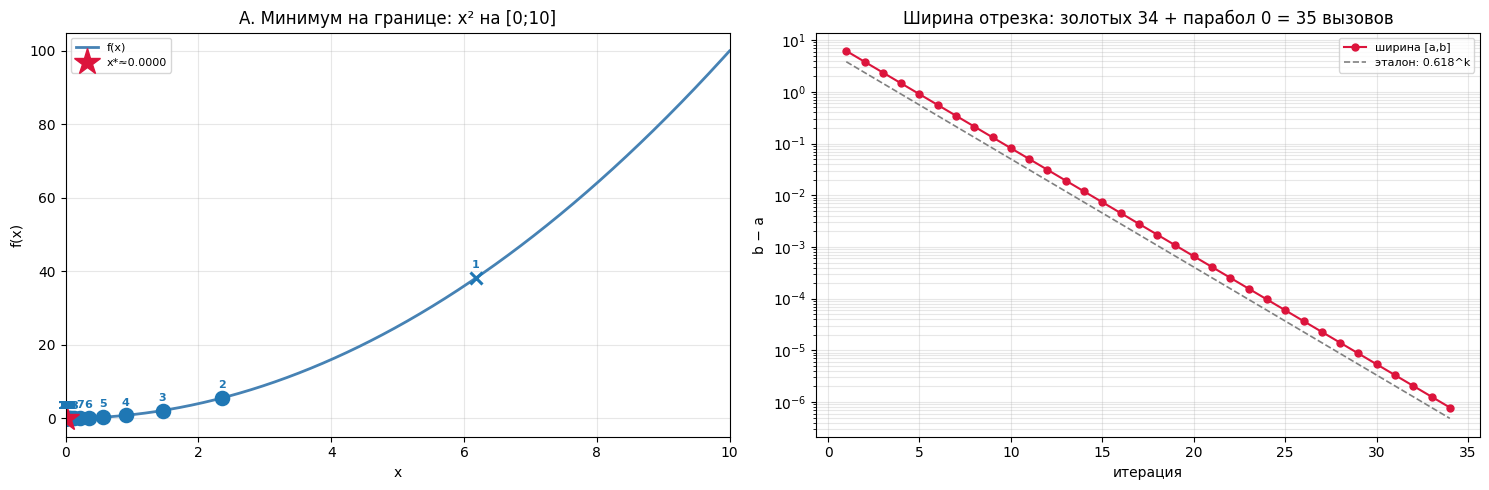

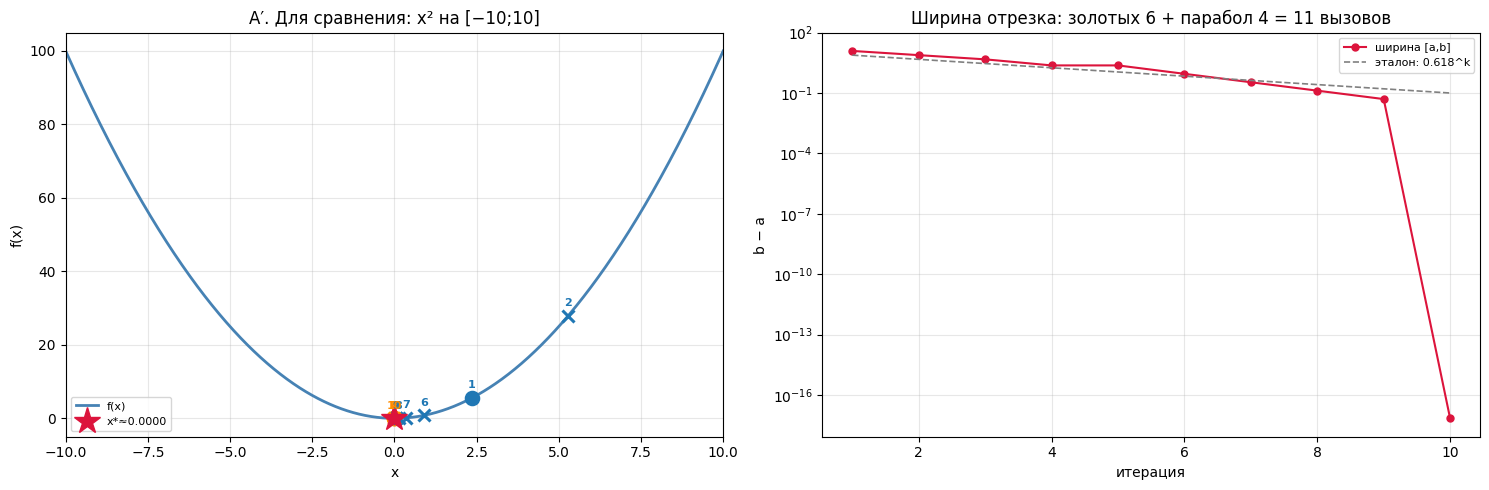

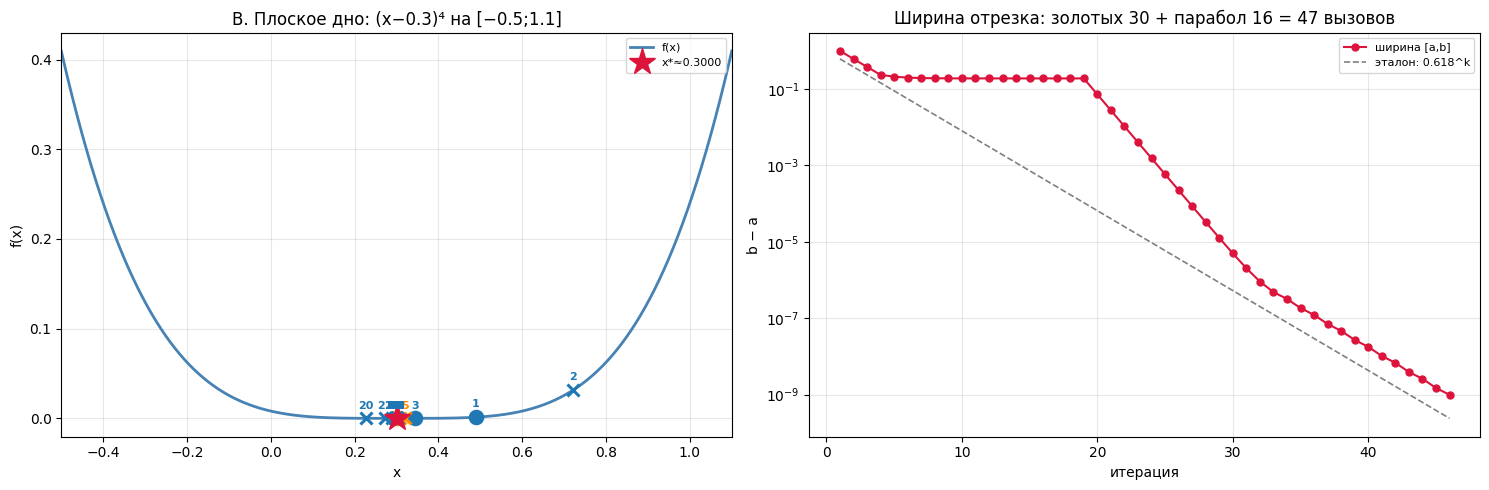

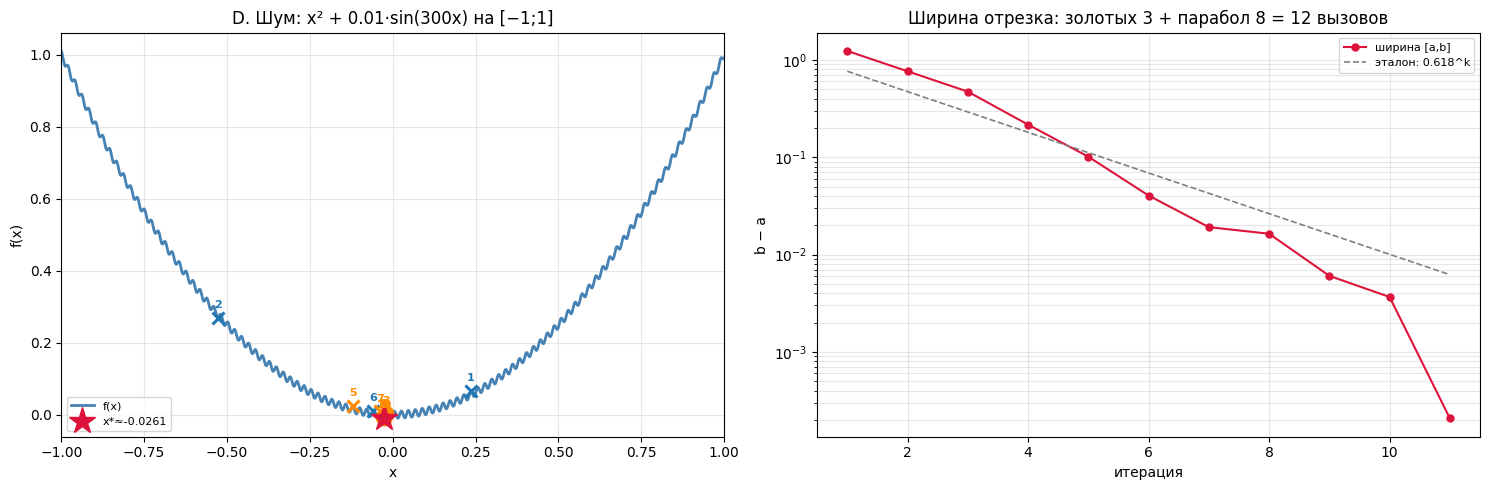


Сводка:
случай                                    x* вызовы золотых парабол
x² на [0;10] (мин. на границе)        0.0000     35     34       0
x² на [−10;10] (мин. внутри)          0.0000     11      6       4
(x−0.3)⁴ на [−0.5;1.1] (плоское дно)    0.3000     47     30      16
x² + 0.01·sin(300x) (шум)            -0.0261     12      3       8


In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt


def brent_trace(f, a, b, eps=1e-6, max_iter=300):
    """Брент с журналом шагов: тип шага, точка u, ширина отрезка."""
    c_gold = (3 - math.sqrt(5)) / 2
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1
    log = []

    for iteration in range(max_iter):
        if (b - a) < eps:
            break

        u = None
        kind = None
        if e != 0 and v != w and w != x and v != x:
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)
            if abs(A) > 1e-12:
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex
                    kind = 'парабола'

        if u is None:
            if x < (a + b) / 2:
                u = x + (b - x) * c_gold
            else:
                u = x - (x - a) * c_gold
            kind = 'золотое'

        e = d
        d = u - x
        fu = f(u)
        func_calls += 1
        accepted = fu <= fx

        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u >= x:
                b = u
            else:
                a = u
            if fu <= fw or w == x:
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

        log.append((kind, u, b - a, accepted))

    return x, fx, func_calls, log


def draw_ineff(title, f, a, b, eps=1e-6, show_xlim=None):
    x, fx, fc, log = brent_trace(f, a, b, eps=eps)
    kinds = [r[0] for r in log]
    n_gold = kinds.count('золотое')
    n_par = kinds.count('парабола')

    fig, (ax, axb) = plt.subplots(1, 2, figsize=(15, 5))
    colors = {'золотое': '#1f77b4', 'парабола': 'darkorange'}

    xs = np.linspace(a, b, 1000)
    ax.plot(xs, [f(v) for v in xs], 'steelblue', lw=2, label='f(x)')
    for i, (kind, u, bw, acc) in enumerate(log):
        c = colors[kind]
        m = 'o' if acc else 'x'
        ax.plot(u, f(u), m, color=c, ms=9, mew=2.2)
        ax.annotate(str(i + 1), (u, f(u)), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=8, color=c, fontweight='bold')
    ax.plot(x, fx, '*', color='crimson', ms=20, label=f'x*≈{x:.4f}')
    if show_xlim:
        ax.set_xlim(*show_xlim)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    widths = [r[2] for r in log]
    iters = list(range(1, len(widths) + 1))
    axb.semilogy(iters, widths, 'o-', color='crimson', ms=5, label='ширина [a,b]')
    w0 = widths[0] if widths else (b - a)
    ref = [w0 * 0.618 ** k for k in range(1, len(widths) + 1)]
    axb.plot(iters, ref, '--', color='gray', lw=1.2, label='эталон: 0.618^k')
    axb.set_title(f'Ширина отрезка: золотых {n_gold} + парабол {n_par} = {fc} вызовов')
    axb.set_xlabel('итерация'); axb.set_ylabel('b − a')
    axb.grid(alpha=0.3, which='both')
    axb.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    return x, fc, n_gold, n_par


summary = []

# Случай A: минимум на границе — парабола не может работать
fA = lambda x: x ** 2
r = draw_ineff('A. Минимум на границе: x² на [0;10]', fA, 0, 10, eps=1e-6, show_xlim=(0, 10))
summary.append(('x² на [0;10] (мин. на границе)', *r))

# Тот же x² с нормально поставленным отрезком
r = draw_ineff("A′. Для сравнения: x² на [−10;10]", fA, -10, 10, eps=1e-6, show_xlim=(-10, 10))
summary.append(('x² на [−10;10] (мин. внутри)', *r))

# Случай B: плоское асимметричное дно
r = draw_ineff('B. Плоское дно: (x−0.3)⁴ на [−0.5;1.1]',
               lambda x: (x - 0.3) ** 4, -0.5, 1.1, eps=1e-9, show_xlim=(-0.5, 1.1))
summary.append(('(x−0.3)⁴ на [−0.5;1.1] (плоское дно)', *r))

# Случай D: шум — застревает на мелком локальном минимуме
r = draw_ineff('D. Шум: x² + 0.01·sin(300x) на [−1;1]',
               lambda x: x ** 2 + 0.01 * math.sin(300 * x), -1, 1, eps=1e-3, show_xlim=(-1, 1))
summary.append(('x² + 0.01·sin(300x) (шум)', *r))

print('\nСводка:')
print(f"{'случай':<34} {'x*':>9} {'вызовы':>6} {'золотых':>6} {'парабол':>7}")
for name, x, fc, ng, np_ in summary:
    print(f'{name:<34} {x:>9.4f} {fc:>6} {ng:>6} {np_:>7}')


## 7. Тесты градиентного спуска (с автоматическим шагом 1/f'')

Градиентный спуск с шагом, привязанным ко второй производной: `x_{k+1} = x_k - f'(x_k)/f''(x_k)`.
Это то же обновление весов, что в классическом градиентном спуске, но вместо постоянного
множителя η стоит честный `1/f''` — а это, по сути, метод Ньютона.

Сравниваем **две версии**:

1. **Без дробления шага** — если после шага `f` выросла, метод сразу отказывается (`ok=False`).
2. **С дроблением шага** — если `f` выросла, шаг уменьшается вдвое, пока `f` не начнёт убывать.


In [13]:
import math

# --- Версия 1: без дробления шага ---
def gradient_descent_plain(f, f1, f2, x0, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x)
        hess = f2(x)
        if hess == 0:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        step = grad / hess
        if not math.isfinite(step):
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        x_new = x - step
        f_new = f(x_new)
        func_calls += 1
        if f_new > f_x:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = x_new
        f_x = f_new
        history_x.append(x)
        history_f.append(f_x)
    return x, f_new, iteration + 1, func_calls, history_x, history_f, False

# --- Версия 2: с дроблением шага ---
def gradient_descent_backtrack(f, f1, f2, x0, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x)
        hess = f2(x)
        if hess == 0:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        step = grad / hess
        if not math.isfinite(step):
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        x_new = x - step
        f_new = f(x_new)
        func_calls += 1
        t = 1.0
        while f_new > f_x:
            t *= 0.5
            if t < 1e-12:
                return x, f_x, iteration + 1, func_calls, history_x, history_f, False
            x_new = x - t * step
            f_new = f(x_new)
            func_calls += 1
        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = x_new
        f_x = f_new
        history_x.append(x)
        history_f.append(f_x)
    return x, f_x, iteration + 1, func_calls, history_x, history_f, False


# --- Тестовые случаи ---
def run_case(name, f, f1, f2, x0):
    xp, fvp, itp, fcp, hxp, hfp, okp = gradient_descent_plain(f, f1, f2, x0)
    xb, fvb, itb, fcb, hxb, hfb, okb = gradient_descent_backtrack(f, f1, f2, x0)
    return name, (xp, itp, fcp, okp), (xb, itb, fcb, okb)

cases = [
    run_case("x^2, старт 3 (мин 0)",
             lambda x: x**2, lambda x: 2*x, lambda x: 2.0, 3.0),
    run_case("(x-2)^2+3, старт 0 (мин 2)",
             lambda x: (x-2)**2+3, lambda x: 2*(x-2), lambda x: 2.0, 0.0),
    run_case("x^4 (плоское дно f''(0)=0)",
             lambda x: x**4, lambda x: 4*x**3, lambda x: 12*x**2, 3.0),
    run_case("1e-14*x^2 (малая кривизна)",
             lambda x: 1e-14*x**2, lambda x: 2e-14*x, lambda x: 2e-14, 3.0),
    run_case("x (линейная, f''=0)",
             lambda x: x, lambda x: 1.0, lambda x: 0.0, 3.0),
    run_case("x^3, старт 1 (перегиб в 0)",
             lambda x: x**3, lambda x: 3*x**2, lambda x: 6*x, 1.0),
    run_case("e^x, старт -30 (минимума нет)",
             lambda x: math.exp(x), lambda x: math.exp(x), lambda x: math.exp(x), -30.0),
    run_case("x^4-6x^2+2x+10 из 0 (максимум 0.168)",
             lambda x: x**4-6*x**2+2*x+10,
             lambda x: 4*x**3-12*x+2, lambda x: 12*x**2-12, 0.0),
    run_case("x^4/4-x^2 из 0.95 (перескок)",
             lambda x: x**4/4-x**2, lambda x: x**3-2*x, lambda x: 3*x**2-2, 0.95),
    run_case("cos(x), старт 2 (мин pi)",
             lambda x: math.cos(x), lambda x: -math.sin(x), lambda x: -math.cos(x), 2.0),
]

print(f"{'случай':>34} | {'без дробления':>24} | {'с дроблением':>24}")
print(f"{'':>34} | {'x':>10} {'it':>3} {'calls':>5} {'ok':>5} | {'x':>10} {'it':>3} {'calls':>5} {'ok':>5}")
for name, (xp, itp, fcp, okp), (xb, itb, fcb, okb) in cases:
    print(f"{name:>34} | {xp:>10.6f} {itp:>3} {fcp:>5} {str(okp):>5} | {xb:>10.6f} {itb:>3} {fcb:>5} {str(okb):>5}")


                            случай |            без дробления |             с дроблением
                                   |          x  it calls    ok |          x  it calls    ok
              x^2, старт 3 (мин 0) |   0.000000   2     3  True |   0.000000   2     3  True
        (x-2)^2+3, старт 0 (мин 2) |   2.000000   2     3  True |   2.000000   2     3  True
        x^4 (плоское дно f''(0)=0) |   0.001353  19    20  True |   0.001353  19    20  True
        1e-14*x^2 (малая кривизна) |   0.000000   2     3  True |   0.000000   2     3  True
               x (линейная, f''=0) |   3.000000   1     1 False |   3.000000   1     1 False
        x^3, старт 1 (перегиб в 0) |   0.000977  10    11  True |   0.000977  10    11  True
     e^x, старт -30 (минимума нет) | -130.000000 100   101 False | -130.000000 100   101 False
x^4-6x^2+2x+10 из 0 (максимум 0.168) |   0.000000   1     2 False |   0.000000   1    41 False
      x^4/4-x^2 из 0.95 (перескок) |   0.950000   1     2 False |   1.

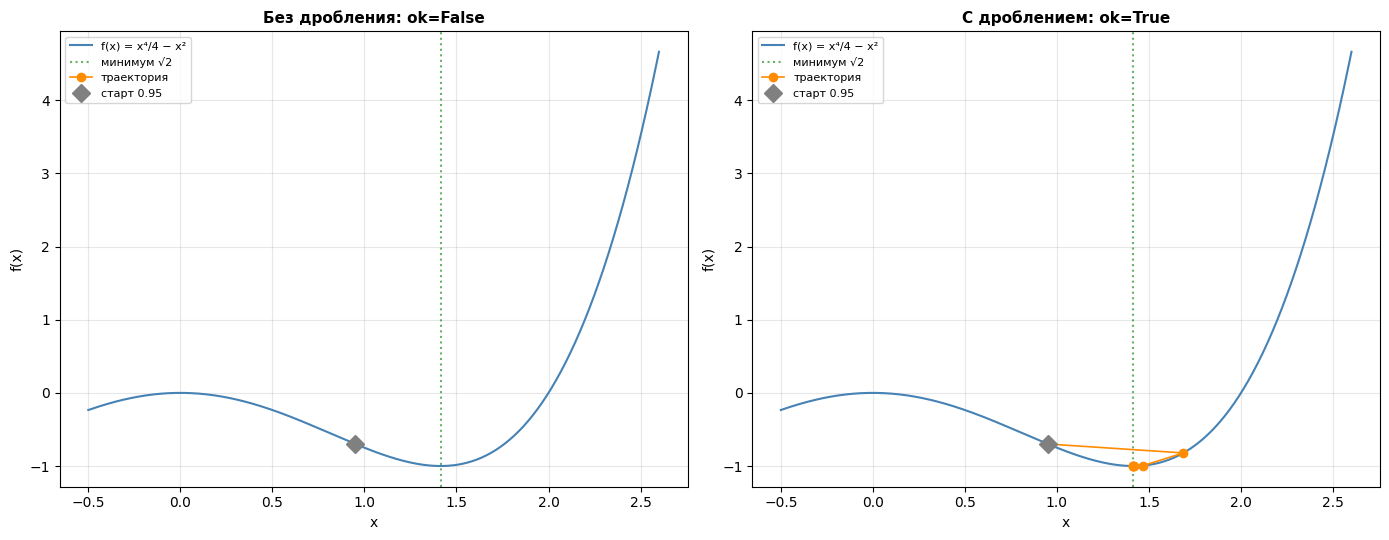

без дробления — траектория: ['0.9500'] (сломался на 1-м шаге)
с дроблением  — траектория: ['0.9500', '1.6868', '1.4687', '1.4171', '1.4142', '1.4142', '1.4142']


In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Ключевой случай: перескок через минимум. x^4/4 - x^2, минимум в sqrt(2).
def f(x):  return x**4/4 - x**2
def f1(x): return x**3 - 2*x
def f2(x): return 3*x**2 - 2

xp, fp, itp, fcp, hxp, hfp, okp = gradient_descent_plain(f, f1, f2, 0.95, eps=1e-6)
xb, fb, itb, fcb, hxb, hfb, okb = gradient_descent_backtrack(f, f1, f2, 0.95, eps=1e-6)

xs = np.linspace(-0.5, 2.6, 600)
ys = [f(x) for x in xs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (hx, ok, title) in zip(axes, [(hxp, okp, 'Без дробления'), (hxb, okb, 'С дроблением')]):
    ax.plot(xs, ys, 'steelblue', lw=1.5, label='f(x) = x⁴/4 − x²')
    ax.axvline(math.sqrt(2), color='green', ls=':', alpha=0.6, label='минимум √2')
    inside = [t for t in hx if -0.5 <= t <= 2.6]
    ax.plot(inside, [f(t) for t in inside], 'o-', color='darkorange', ms=6, lw=1.2, label='траектория')
    if inside:
        ax.plot(inside[0], f(inside[0]), 'D', color='gray', ms=9, label='старт 0.95')
    ax.set_title(f'{title}: ok={ok}', fontsize=11, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('без дробления — траектория:', [f'{v:.4f}' for v in hxp], '(сломался на 1-м шаге)')
print('с дроблением  — траектория:', [f'{v:.4f}' for v in hxb])


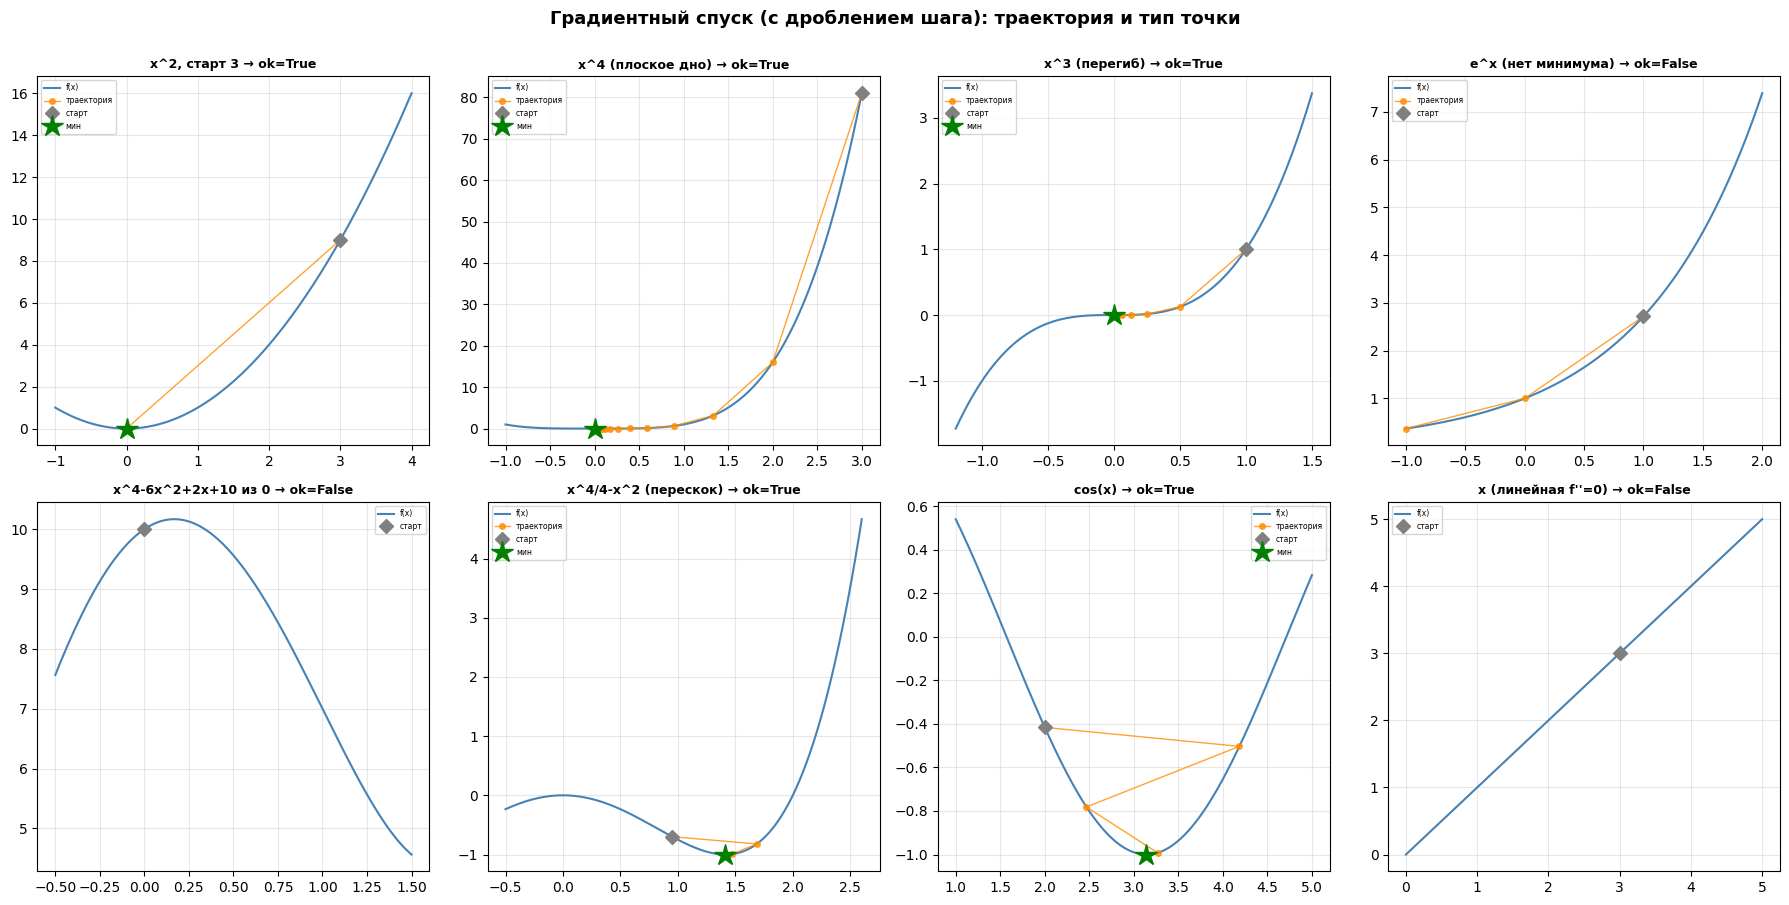

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

def plot_case(ax, name, f, f1, f2, x0, x_range, use_backtrack=True):
    a, b = x_range
    xs = np.linspace(a, b, 600)
    ax.plot(xs, [f(x) for x in xs], 'steelblue', lw=1.5, label='f(x)')
    fn = gradient_descent_backtrack if use_backtrack else gradient_descent_plain
    xf, fv, it, fc, hx, hf, ok = fn(f, f1, f2, x0, eps=1e-6, max_iter=100)
    inside = [t for t in hx if a <= t <= b][:15]
    if len(inside) > 1:
        ax.plot(inside, [f(t) for t in inside], 'o-', color='darkorange', ms=4, lw=1, alpha=0.8, label='траектория')
    if a <= x0 <= b:
        ax.plot(x0, f(x0), 'D', color='gray', ms=7, label='старт')
    # тип найденной точки по знаку f''
    if ok and math.isfinite(f2(xf)) and f2(xf) != 0:
        kind = 'мин' if f2(xf) > 0 else 'макс'
        color = 'green' if f2(xf) > 0 else 'red'
        ax.plot(xf, f(xf), '*', color=color, ms=16, label=kind)
    ax.set_title(f'{name} → ok={ok}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=5.5, loc='best')

cases = [
    ("x^2, старт 3", lambda x: x**2, lambda x: 2*x, lambda x: 2.0, 3.0, (-1, 4)),
    ("x^4 (плоское дно)", lambda x: x**4, lambda x: 4*x**3, lambda x: 12*x**2, 3.0, (-1, 3)),
    ("x^3 (перегиб)", lambda x: x**3, lambda x: 3*x**2, lambda x: 6*x, 1.0, (-1.2, 1.5)),
    ("e^x (нет минимума)", lambda x: math.exp(x), lambda x: math.exp(x), lambda x: math.exp(x), 1.0, (-1, 2)),
    ("x^4-6x^2+2x+10 из 0", lambda x: x**4-6*x**2+2*x+10,
     lambda x: 4*x**3-12*x+2, lambda x: 12*x**2-12, 0.0, (-0.5, 1.5)),
    ("x^4/4-x^2 (перескок)", lambda x: x**4/4-x**2, lambda x: x**3-2*x, lambda x: 3*x**2-2, 0.95, (-0.5, 2.6)),
    ("cos(x)", lambda x: math.cos(x), lambda x: -math.sin(x), lambda x: -math.cos(x), 2.0, (1, 5)),
    ("x (линейная f''=0)", lambda x: x, lambda x: 1.0, lambda x: 0.0, 3.0, (0, 5)),
]

cols = 4
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(18, 9))
axes = axes.flatten()
for ax, case in zip(axes, cases):
    plot_case(ax, *case)
fig.suptitle('Градиентный спуск (с дроблением шага): траектория и тип точки',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


**Что показали тесты.**

- **Шаг `1/f''` — честная замена константе η.** На всех 11 задачах с минимумом метод сходится за 2–4 итерации. Сравнение с постоянным шагом — в `gradient_descent.ipynb`: с лучшим постоянным η = 1/f″(x*) спуск сходится так же быстро (2–4 итерации), но такой η нужно заранее знать — кривизну в точке минимума. Одного η на все задачи не существует: нужные значения отличаются в десятки тысяч раз (0.008 у коробки против 462 у EOQ). Адаптивный шаг выигрывает не скоростью, а тем, что η подбирать не нужно — длина шага берётся из локальной кривизны по ходу движения.
- **Дробление чинит только перескоки.** Единственный случай, где версии расходятся, — `x⁴/4 − x²` из 0.95: полный шаг перебрасывает через минимум (f растёт), без дробления метод ложно отказывается, с дроблением — гасит шаг и доходит до `√2`. На всех остальных тестах версии идентичны: дробление не ломает нормальную работу.
- **Ограничения остаются.** `x³` из 1 «сходится» в точку перегиба, а `x⁴−6x²+2x+10` из 0 — в максимум: критерий `f′ ≈ 0` не отличает тип точки, нужен знак `f″`. `eˣ` и линейная `f″=0` честно дают `ok=False`. А на максимуме дробление тратит десятки вызовов впустую, безуспешно ища убывание, — плата за гарантию монотонности.


---
*Ноутбук сгенерирован переносом ячеек из `zadachi_metody_minimuma.ipynb`. Вывод очищен; для просмотра графиков и таблиц — `Restart Kernel and Run All`.*
